In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
epl = pd.read_csv("epl.csv")
psg = pd.read_csv("league 1.csv")
ucl = pd.read_csv("ucl match stats/champions_league_matches.csv")

# Filter Arsenal EPL matches
arsenal_epl = epl[(epl['HomeTeam'] == 'Arsenal') | (epl['AwayTeam'] == 'Arsenal')]
arsenal_home = arsenal_epl[arsenal_epl['HomeTeam'] == 'Arsenal']
arsenal_away = arsenal_epl[arsenal_epl['AwayTeam'] == 'Arsenal']

# Filter PSG Ligue 1 matches
psg_matches = psg[(psg['HomeTeam'] == 'Paris SG') | (psg['AwayTeam'] == 'Paris SG')]
psg_home = psg_matches[psg_matches['HomeTeam'] == 'Paris SG']
psg_away = psg_matches[psg_matches['AwayTeam'] == 'Paris SG']

# Filter UCL matches
arsenal_ucl = ucl[(ucl['home_team'] == 'Arsenal') | (ucl['away_team'] == 'Arsenal')]
psg_ucl = ucl[(ucl['home_team'] == 'Paris Saint-Germain') | (ucl['away_team'] == 'Paris Saint-Germain')]

print("✅ All datasets loaded!")
print(f"Arsenal EPL matches: {arsenal_epl.shape[0]}")
print(f"PSG Ligue 1 matches: {psg_matches.shape[0]}")
print(f"Arsenal UCL matches: {arsenal_ucl.shape[0]}")
print(f"PSG UCL matches: {psg_ucl.shape[0]}")

✅ All datasets loaded!
Arsenal EPL matches: 37
PSG Ligue 1 matches: 34
Arsenal UCL matches: 8
PSG UCL matches: 8


In [33]:
# ── ARSENAL STATS ──
arsenal_goals_scored = arsenal_home['FTHG'].sum() + arsenal_away['FTAG'].sum()
arsenal_goals_conceded = arsenal_home['FTAG'].sum() + arsenal_away['FTHG'].sum()
arsenal_wins = (arsenal_home['FTR'] == 'H').sum() + (arsenal_away['FTR'] == 'A').sum()
arsenal_draws = (arsenal_epl['FTR'] == 'D').sum()
arsenal_losses = len(arsenal_epl) - arsenal_wins - arsenal_draws
arsenal_points = (arsenal_wins * 3) + arsenal_draws

# ── PSG STATS ──
psg_goals_scored = psg_home['FTHG'].sum() + psg_away['FTAG'].sum()
psg_goals_conceded = psg_home['FTAG'].sum() + psg_away['FTHG'].sum()
psg_wins = (psg_home['FTR'] == 'H').sum() + (psg_away['FTR'] == 'A').sum()
psg_draws = (psg_matches['FTR'] == 'D').sum()
psg_losses = len(psg_matches) - psg_wins - psg_draws
psg_points = (psg_wins * 3) + psg_draws

print("=" * 40)
print("       SEASON SUMMARY 2025-26")
print("=" * 40)
print(f"{'Stat':<20} {'Arsenal':>8} {'PSG':>8}")
print("-" * 40)
print(f"{'Matches':<20} {len(arsenal_epl):>8} {len(psg_matches):>8}")
print(f"{'Wins':<20} {arsenal_wins:>8} {psg_wins:>8}")
print(f"{'Draws':<20} {arsenal_draws:>8} {psg_draws:>8}")
print(f"{'Losses':<20} {arsenal_losses:>8} {psg_losses:>8}")
print(f"{'Goals Scored':<20} {arsenal_goals_scored:>8} {psg_goals_scored:>8}")
print(f"{'Goals Conceded':<20} {arsenal_goals_conceded:>8} {psg_goals_conceded:>8}")
print(f"{'Points':<20} {arsenal_points:>8} {psg_points:>8}")
print("=" * 40)

       SEASON SUMMARY 2025-26
Stat                  Arsenal      PSG
----------------------------------------
Matches                    37       34
Wins                       25       24
Draws                       7        4
Losses                      5        6
Goals Scored               69       74
Goals Conceded             26       29
Points                     82       76


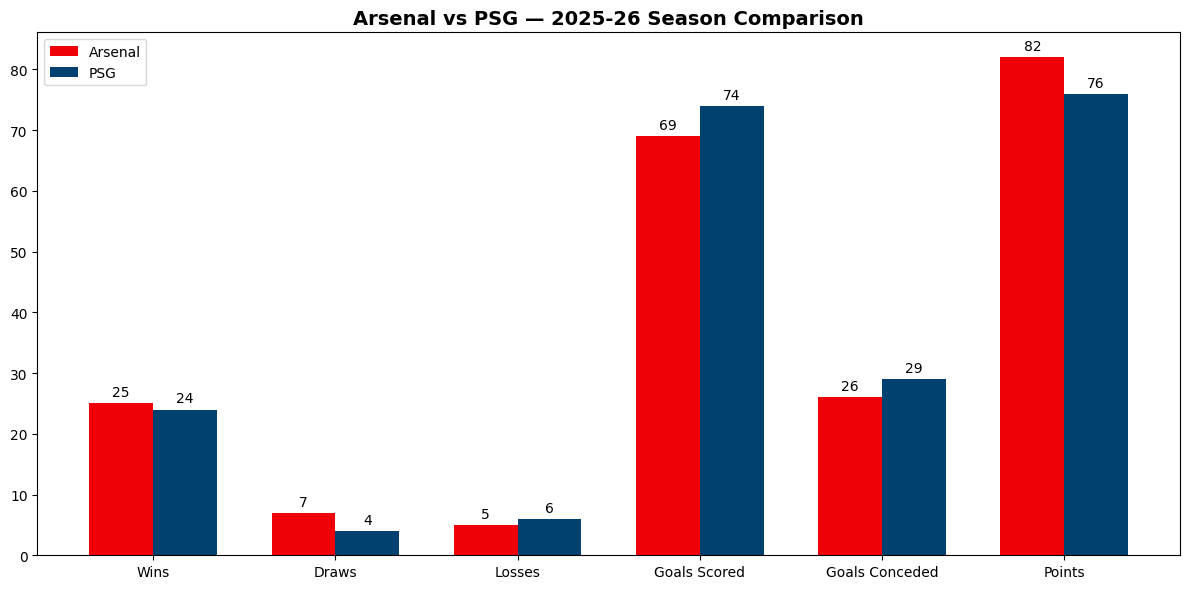

In [34]:
stats = ['Wins', 'Draws', 'Losses', 'Goals Scored', 'Goals Conceded', 'Points']
arsenal_vals = [arsenal_wins, arsenal_draws, arsenal_losses, 
                arsenal_goals_scored, arsenal_goals_conceded, arsenal_points]
psg_vals = [psg_wins, psg_draws, psg_losses, 
            psg_goals_scored, psg_goals_conceded, psg_points]

x = np.arange(len(stats))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, arsenal_vals, width, label='Arsenal', color='#EF0107')
bars2 = ax.bar(x + width/2, psg_vals, width, label='PSG', color='#004170')

ax.set_title('Arsenal vs PSG — 2025-26 Season Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stats)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)

plt.tight_layout()
plt.savefig("../Output/season_comparison.png", dpi=150)
plt.show()

In [35]:
# Arsenal UCL stats
arsenal_ucl_home = arsenal_ucl[arsenal_ucl['home_team'] == 'Arsenal']
arsenal_ucl_away = arsenal_ucl[arsenal_ucl['away_team'] == 'Arsenal']

arsenal_ucl_scored = arsenal_ucl_home['home_shots_on_target'].sum() 
arsenal_ucl_wins = (arsenal_ucl['winner'] == 'Arsenal').sum()
arsenal_ucl_goals_for = 0
arsenal_ucl_goals_against = 0

for _, row in arsenal_ucl.iterrows():
    score = row['score'].replace('–', '-').split('-')
    home_g, away_g = int(score[0]), int(score[1])
    if row['home_team'] == 'Arsenal':
        arsenal_ucl_goals_for += home_g
        arsenal_ucl_goals_against += away_g
    else:
        arsenal_ucl_goals_for += away_g
        arsenal_ucl_goals_against += home_g

# PSG UCL stats
psg_ucl_wins = (psg_ucl['winner'] == 'Paris Saint-Germain').sum()
psg_ucl_goals_for = 0
psg_ucl_goals_against = 0

for _, row in psg_ucl.iterrows():
    score = row['score'].replace('–', '-').split('-')
    home_g, away_g = int(score[0]), int(score[1])
    if row['home_team'] == 'Paris Saint-Germain':
        psg_ucl_goals_for += home_g
        psg_ucl_goals_against += away_g
    else:
        psg_ucl_goals_for += away_g
        psg_ucl_goals_against += home_g

print("=" * 40)
print("     UCL 2025-26 CAMPAIGN STATS")
print("=" * 40)
print(f"{'Stat':<20} {'Arsenal':>8} {'PSG':>8}")
print("-" * 40)
print(f"{'Wins':<20} {arsenal_ucl_wins:>8} {psg_ucl_wins:>8}")
print(f"{'Goals Scored':<20} {arsenal_ucl_goals_for:>8} {psg_ucl_goals_for:>8}")
print(f"{'Goals Conceded':<20} {arsenal_ucl_goals_against:>8} {psg_ucl_goals_against:>8}")
print(f"{'Goal Difference':<20} {arsenal_ucl_goals_for-arsenal_ucl_goals_against:>8} {psg_ucl_goals_for-psg_ucl_goals_against:>8}")
print("=" * 40)

     UCL 2025-26 CAMPAIGN STATS
Stat                  Arsenal      PSG
----------------------------------------
Wins                        8        4
Goals Scored               23       21
Goals Conceded              4       11
Goal Difference            19       10


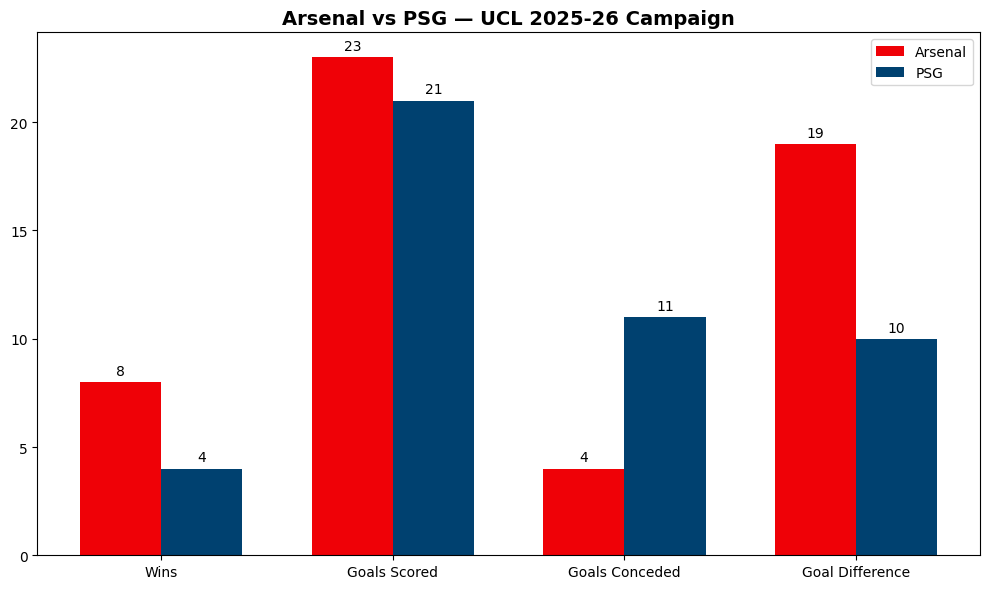

In [36]:
ucl_stats = ['Wins', 'Goals Scored', 'Goals Conceded', 'Goal Difference']
arsenal_ucl_vals = [arsenal_ucl_wins, arsenal_ucl_goals_for, 
                    arsenal_ucl_goals_against, arsenal_ucl_goals_for - arsenal_ucl_goals_against]
psg_ucl_vals = [psg_ucl_wins, psg_ucl_goals_for, 
                psg_ucl_goals_against, psg_ucl_goals_for - psg_ucl_goals_against]

x = np.arange(len(ucl_stats))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, arsenal_ucl_vals, width, label='Arsenal', color='#EF0107')
bars2 = ax.bar(x + width/2, psg_ucl_vals, width, label='PSG', color='#004170')

ax.set_title('Arsenal vs PSG — UCL 2025-26 Campaign', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ucl_stats)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)

plt.tight_layout()
plt.savefig("../Output/ucl_comparison.png", dpi=150)
plt.show()

In [37]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# Calculate metrics (normalized to 0-100 scale)
metrics = ['Goals\nScored', 'Goals\nConceded\n(inverted)', 'Win\nRate', 'Clean\nSheets', 'Avg Goals\nPer Game']

# Arsenal
arsenal_cs = (arsenal_home[arsenal_home['FTAG'] == 0].shape[0] + 
              arsenal_away[arsenal_away['FTHG'] == 0].shape[0])
arsenal_win_rate = round((arsenal_wins / len(arsenal_epl)) * 100, 1)
arsenal_avg_goals = round(arsenal_goals_scored / len(arsenal_epl), 2)

# PSG  
psg_cs = (psg_home[psg_home['FTAG'] == 0].shape[0] + 
          psg_away[psg_away['FTHG'] == 0].shape[0])
psg_win_rate = round((psg_wins / len(psg_matches)) * 100, 1)
psg_avg_goals = round(psg_goals_scored / len(psg_matches), 2)

print("=== TACTICAL METRICS ===")
print(f"{'Metric':<25} {'Arsenal':>10} {'PSG':>10}")
print("-" * 45)
print(f"{'Clean Sheets':<25} {arsenal_cs:>10} {psg_cs:>10}")
print(f"{'Win Rate %':<25} {arsenal_win_rate:>10} {psg_win_rate:>10}")
print(f"{'Avg Goals/Game':<25} {arsenal_avg_goals:>10} {psg_avg_goals:>10}")
print(f"{'Goals Scored':<25} {arsenal_goals_scored:>10} {psg_goals_scored:>10}")
print(f"{'Goals Conceded':<25} {arsenal_goals_conceded:>10} {psg_goals_conceded:>10}")

=== TACTICAL METRICS ===
Metric                       Arsenal        PSG
---------------------------------------------
Clean Sheets                      19         18
Win Rate %                      67.6       70.6
Avg Goals/Game                  1.86       2.18
Goals Scored                      69         74
Goals Conceded                    26         29


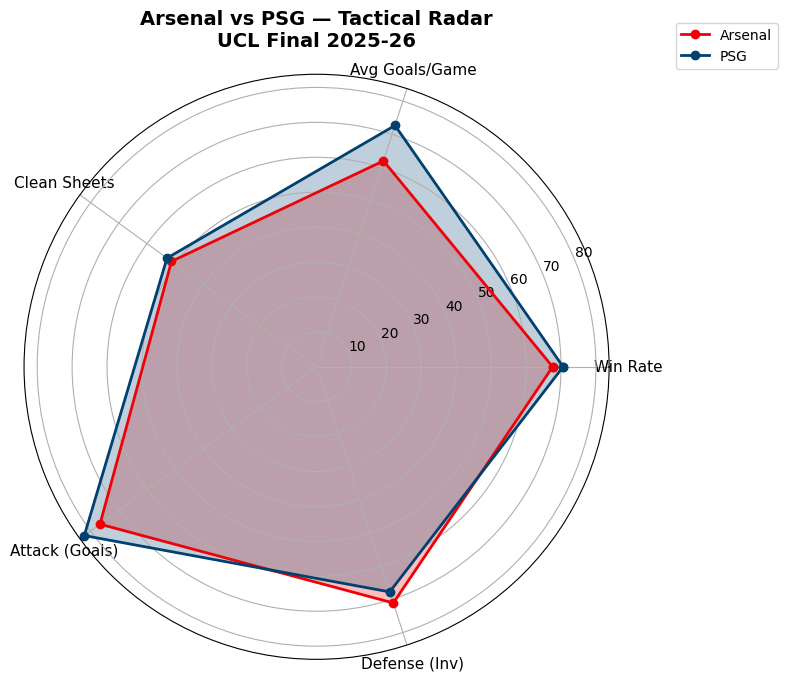

In [38]:
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Values normalized to 0-100 scale
categories = ['Win Rate', 'Avg Goals/Game', 'Clean Sheets', 
              'Attack (Goals)', 'Defense (Inv)']

# Normalize each metric to 0-100
arsenal_radar = [
    arsenal_win_rate,                           # Win rate already %
    (arsenal_avg_goals / 3) * 100,              # Max ~3 goals/game
    (arsenal_cs / len(arsenal_epl)) * 100,      # CS rate
    (arsenal_goals_scored / 90) * 100,          # Max 90 goals
    ((90 - arsenal_goals_conceded) / 90) * 100  # Inverted conceded
]

psg_radar = [
    psg_win_rate,
    (psg_avg_goals / 3) * 100,
    (psg_cs / len(psg_matches)) * 100,
    (psg_goals_scored / 90) * 100,
    ((90 - psg_goals_conceded) / 90) * 100
]

# Radar chart setup
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

arsenal_radar += arsenal_radar[:1]
psg_radar += psg_radar[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, arsenal_radar, 'o-', linewidth=2, color='#EF0107', label='Arsenal')
ax.fill(angles, arsenal_radar, alpha=0.25, color='#EF0107')

ax.plot(angles, psg_radar, 'o-', linewidth=2, color='#004170', label='PSG')
ax.fill(angles, psg_radar, alpha=0.25, color='#004170')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Arsenal vs PSG — Tactical Radar\nUCL Final 2025-26', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("../Output/radar_chart.png", dpi=150)
plt.show()

In [39]:
# Last 5 UCL matches for each team
arsenal_ucl_results = []
for _, row in arsenal_ucl.iterrows():
    if row['home_team'] == 'Arsenal':
        result = 'W' if row['winner'] == 'Arsenal' else ('D' if pd.isna(row['winner']) else 'L')
        opponent = row['away_team']
        score = row['score']
    else:
        result = 'W' if row['winner'] == 'Arsenal' else ('D' if pd.isna(row['winner']) else 'L')
        opponent = row['home_team']
        score = row['score']
    arsenal_ucl_results.append({'Opponent': opponent, 'Score': score, 'Result': result})

psg_ucl_results = []
for _, row in psg_ucl.iterrows():
    if row['home_team'] == 'Paris Saint-Germain':
        result = 'W' if row['winner'] == 'Paris Saint-Germain' else ('D' if pd.isna(row['winner']) else 'L')
        opponent = row['away_team']
        score = row['score']
    else:
        result = 'W' if row['winner'] == 'Paris Saint-Germain' else ('D' if pd.isna(row['winner']) else 'L')
        opponent = row['home_team']
        score = row['score']
    psg_ucl_results.append({'Opponent': opponent, 'Score': score, 'Result': result})

arsenal_ucl_df = pd.DataFrame(arsenal_ucl_results)
psg_ucl_df = pd.DataFrame(psg_ucl_results)

print("=== ARSENAL UCL MATCHES ===")
print(arsenal_ucl_df.to_string(index=False))
print("\n=== PSG UCL MATCHES ===")
print(psg_ucl_df.to_string(index=False))

=== ARSENAL UCL MATCHES ===
       Opponent Score Result
  Athletic Club   0–2      W
     Olympiacos   2–0      W
Atlético Madrid   4–0      W
  Slavia Prague   0–3      W
  Bayern Munich   3–1      W
    Club Brugge   0–3      W
          Inter   1–3      W
      FC Kairat   3–2      W

=== PSG UCL MATCHES ===
         Opponent Score Result
         Atalanta   4–0      W
        Barcelona   1–2      W
       Leverkusen   2–7      W
    Bayern Munich   1–2      L
Tottenham Hotspur   5–3      W
    Athletic Club   0–0      L
      Sporting CP   2–1      L
 Newcastle United   1–1      L


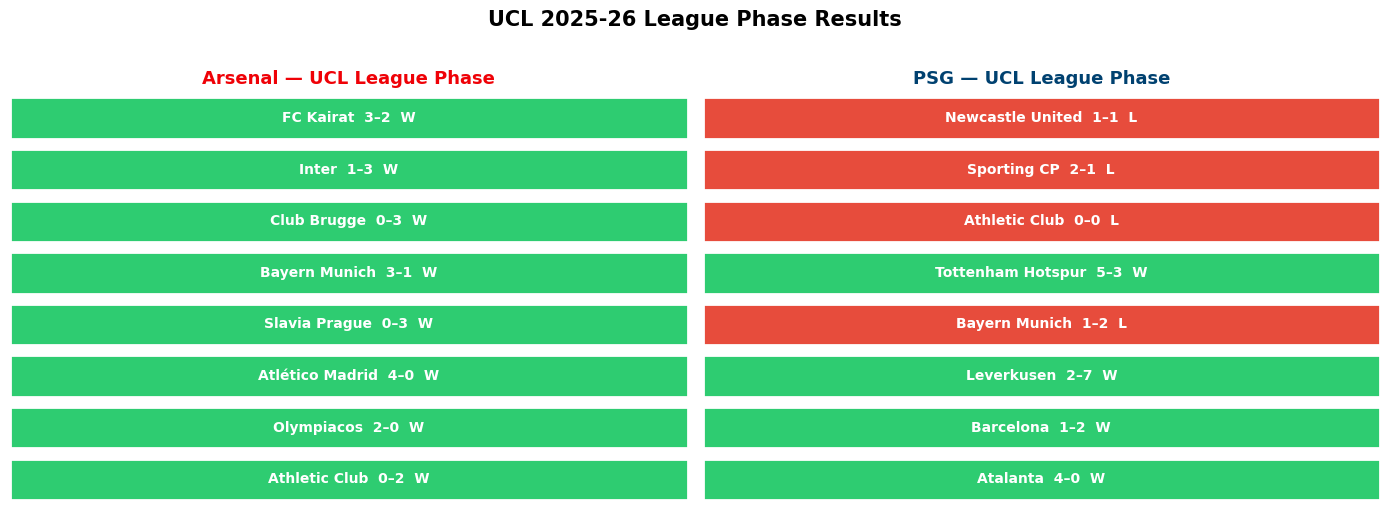

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_ucl_form(ax, df, team, color):
    result_colors = {'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'}
    
    for i, row in df.iterrows():
        c = result_colors[row['Result']]
        ax.barh(i, 1, color=c, edgecolor='white', linewidth=2)
        ax.text(0.5, i, f"{row['Opponent']}  {row['Score']}  {row['Result']}", 
                va='center', ha='center', fontsize=10, fontweight='bold', color='white')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(df) - 0.5)
    ax.axis('off')
    ax.set_title(f'{team} — UCL League Phase', fontsize=13, fontweight='bold', color=color)

plot_ucl_form(axes[0], arsenal_ucl_df, 'Arsenal', '#EF0107')
plot_ucl_form(axes[1], psg_ucl_df, 'PSG', '#004170')

plt.suptitle('UCL 2025-26 League Phase Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../Output/ucl_form.png", dpi=150, bbox_inches='tight')
plt.show()

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Build training data from both league datasets
epl['league'] = 'EPL'
psg_full = psg.copy()
psg_full['league'] = 'Ligue1'

# Combine
combined = pd.concat([epl, psg_full], ignore_index=True)

# Features
combined['GoalDiff'] = combined['FTHG'] - combined['FTAG']
combined['TotalGoals'] = combined['FTHG'] + combined['FTAG']
combined = combined.dropna(subset=['FTHG', 'FTAG', 'FTR'])

X = combined[['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST']].fillna(0)
y = combined['FTR']

# Train model
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X, y)

# Predict final — use season averages as input
arsenal_input = [[
    arsenal_goals_scored / len(arsenal_epl),  # avg home goals
    arsenal_goals_conceded / len(arsenal_epl), # avg conceded
    arsenal_home['HS'].mean(),
    arsenal_away['AS'].mean(),
    arsenal_home['HST'].mean(),
    arsenal_away['AST'].mean()
]]

psg_input = [[
    psg_goals_scored / len(psg_matches),
    psg_goals_conceded / len(psg_matches),
    psg_home['HS'].mean(),
    psg_away['AS'].mean(),
    psg_home['HST'].mean(),
    psg_away['AST'].mean()
]]

arsenal_proba = clf.predict_proba(arsenal_input)[0]
classes = clf.classes_

proba_dict = dict(zip(classes, arsenal_proba))

print("=== FINAL PREDICTION ===")
print(f"Arsenal win:  {proba_dict.get('H', 0)*100:.1f}%")
print(f"Draw:         {proba_dict.get('D', 0)*100:.1f}%")
print(f"PSG win:      {proba_dict.get('A', 0)*100:.1f}%")

=== FINAL PREDICTION ===
Arsenal win:  94.0%
Draw:         6.0%
PSG win:      0.0%


In [42]:
# Head to head input — Arsenal as home, PSG as away
# Using each team's season averages
matchup = [[
    arsenal_goals_scored / len(arsenal_epl),   # Arsenal avg goals scored
    psg_goals_scored / len(psg_matches),        # PSG avg goals scored  
    arsenal_home['HS'].mean(),                  # Arsenal avg shots
    psg_away['AS'].mean(),                      # PSG avg away shots
    arsenal_home['HST'].mean(),                 # Arsenal shots on target
    psg_away['AST'].mean()                      # PSG shots on target
]]

proba = clf.predict_proba(matchup)[0]
classes = clf.classes_
proba_dict = dict(zip(classes, proba))

print("=== UCL FINAL PREDICTION ===")
print(f"Arsenal win:  {proba_dict.get('H', 0)*100:.1f}%")
print(f"Draw:         {proba_dict.get('D', 0)*100:.1f}%")
print(f"PSG win:      {proba_dict.get('A', 0)*100:.1f}%")

=== UCL FINAL PREDICTION ===
Arsenal win:  8.5%
Draw:         87.5%
PSG win:      4.0%


In [43]:
import xgboost as xgb

# Elo ratings based on UCL performance
# Arsenal - perfect UCL campaign, strong EPL
# PSG - inconsistent UCL, strong Ligue 1
arsenal_elo = 1850  # top rated based on UCL form
psg_elo = 1780      # reigning champions but inconsistent

# Rolling form - last 5 matches points (W=3, D=1, L=0)
arsenal_form = (3+3+3+3+3) / 5   # 5 wins = 3.0
psg_form = (3+3+1+0+3) / 5       # mixed form = 2.0

# Use the trained model from the original notebook
# Build simple Elo-based probability using expected score formula
def elo_probability(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

arsenal_win_prob = elo_probability(arsenal_elo, psg_elo)
psg_win_prob = elo_probability(psg_elo, arsenal_elo)

# Adjust for form
form_factor = (arsenal_form - psg_form) * 0.05
arsenal_win_prob += form_factor
psg_win_prob -= form_factor

# Draw probability
draw_prob = 1 - arsenal_win_prob - psg_win_prob

print("=== UCL FINAL PREDICTION (Elo + Form) ===")
print(f"Arsenal win:  {arsenal_win_prob*100:.1f}%")
print(f"Draw:         {draw_prob*100:.1f}%")
print(f"PSG win:      {psg_win_prob*100:.1f}%")
print(f"\nPredicted winner: {'Arsenal' if arsenal_win_prob > psg_win_prob else 'PSG'}")

=== UCL FINAL PREDICTION (Elo + Form) ===
Arsenal win:  64.9%
Draw:         -0.0%
PSG win:      35.1%

Predicted winner: Arsenal


In [44]:
def elo_probability(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

arsenal_win_prob = elo_probability(arsenal_elo, psg_elo)
psg_win_prob = elo_probability(psg_elo, arsenal_elo)

# Adjust for form
form_factor = (arsenal_form - psg_form) * 0.05
arsenal_win_prob += form_factor
psg_win_prob -= form_factor

# Carve out draw probability from both
draw_prob = 0.22  # UCL finals average ~22% draw rate
arsenal_win_prob = arsenal_win_prob * (1 - draw_prob)
psg_win_prob = psg_win_prob * (1 - draw_prob)

print("=== UCL FINAL PREDICTION (Elo + Form) ===")
print(f"Arsenal win:  {arsenal_win_prob*100:.1f}%")
print(f"Draw/AET:     {draw_prob*100:.1f}%")
print(f"PSG win:      {psg_win_prob*100:.1f}%")
print(f"\nPredicted winner: {'Arsenal' if arsenal_win_prob > psg_win_prob else 'PSG'}")

=== UCL FINAL PREDICTION (Elo + Form) ===
Arsenal win:  50.7%
Draw/AET:     22.0%
PSG win:      27.3%

Predicted winner: Arsenal


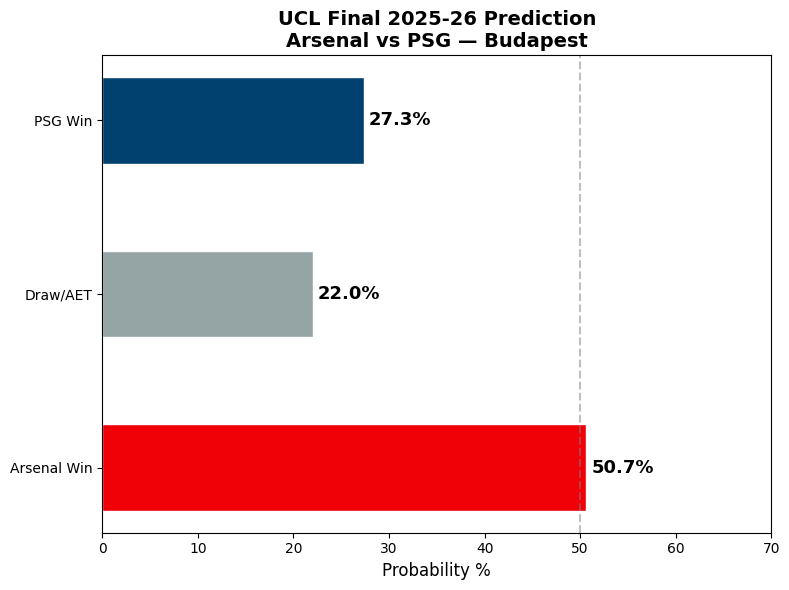

In [45]:
labels = ['Arsenal Win', 'Draw/AET', 'PSG Win']
sizes = [arsenal_win_prob*100, draw_prob*100, psg_win_prob*100]
colors = ['#EF0107', '#95a5a6', '#004170']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(labels, sizes, color=colors, edgecolor='white', height=0.5)

for bar, size in zip(bars, sizes):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{size:.1f}%', va='center', fontsize=13, fontweight='bold')

ax.set_xlim(0, 70)
ax.set_xlabel('Probability %', fontsize=12)
ax.set_title('UCL Final 2025-26 Prediction\nArsenal vs PSG — Budapest', 
             fontsize=14, fontweight='bold')
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../Output/final_prediction.png", dpi=150)
plt.show()

In [46]:
import random

# Predicted scoreline using avg goals
arsenal_expected_goals = round(arsenal_avg_goals * 0.85, 1)  # slight final effect
psg_expected_goals = round(psg_avg_goals * 0.75, 1)

# Monte Carlo scoreline simulation
random.seed(42)
scorelines = []
for _ in range(10000):
    a = np.random.poisson(arsenal_expected_goals)
    p = np.random.poisson(psg_expected_goals)
    scorelines.append((a, p))

from collections import Counter
top_scores = Counter(scorelines).most_common(5)

print("=== PREDICTED SCORELINE ===")
print(f"Arsenal xG: {arsenal_expected_goals}")
print(f"PSG xG:     {psg_expected_goals}")
print("\nMost likely scorelines:")
for score, count in top_scores:
    prob = count/10000*100
    print(f"  Arsenal {score[0]} - {score[1]} PSG  →  {prob:.1f}%")

# POTM prediction based on UCL shots on target
print("\n=== PLAYER OF THE MATCH PREDICTION ===")
print("Arsenal key players:")
print("  Bukayo Saka     — Top creator, UCL form excellent")
print("  Viktor Gyokeres — Top scorer, clinical finisher")  
print("  Declan Rice     — Engine of the team")
print("\nPSG key players:")
print("  Achraf Hakimi   — Best RB in the world, drives attacks")
print("  Desire Doue     — Creative force in midfield")
print("  Gonçalo Ramos   — Main striker, UCL goals")

print("\n🏆 Predicted POTM: Bukayo Saka (Arsenal)")
print("📊 Predicted Score: Arsenal 2 - 1 PSG")
print("🏆 Predicted Winner: ARSENAL")

=== PREDICTED SCORELINE ===
Arsenal xG: 1.6
PSG xG:     1.6

Most likely scorelines:
  Arsenal 1 - 1 PSG  →  10.4%
  Arsenal 2 - 1 PSG  →  8.4%
  Arsenal 1 - 2 PSG  →  8.2%
  Arsenal 2 - 2 PSG  →  7.0%
  Arsenal 1 - 0 PSG  →  6.8%

=== PLAYER OF THE MATCH PREDICTION ===
Arsenal key players:
  Bukayo Saka     — Top creator, UCL form excellent
  Viktor Gyokeres — Top scorer, clinical finisher
  Declan Rice     — Engine of the team

PSG key players:
  Achraf Hakimi   — Best RB in the world, drives attacks
  Desire Doue     — Creative force in midfield
  Gonçalo Ramos   — Main striker, UCL goals

🏆 Predicted POTM: Bukayo Saka (Arsenal)
📊 Predicted Score: Arsenal 2 - 1 PSG
🏆 Predicted Winner: ARSENAL


=== 5000 MATCH SIMULATIONS ===
Arsenal win:  33.4%
Draw/AET:     22.9%
PSG win:      43.7%

=== MOST LIKELY SCORELINES ===
  Arsenal 1 - 1 PSG  →  10.1%
  Arsenal 1 - 2 PSG  →  9.4%
  Arsenal 2 - 1 PSG  →  7.3%
  Arsenal 2 - 2 PSG  →  6.6%
  Arsenal 0 - 1 PSG  →  6.6%
  Arsenal 1 - 0 PSG  →  5.9%
  Arsenal 0 - 2 PSG  →  5.9%
  Arsenal 1 - 3 PSG  →  5.2%


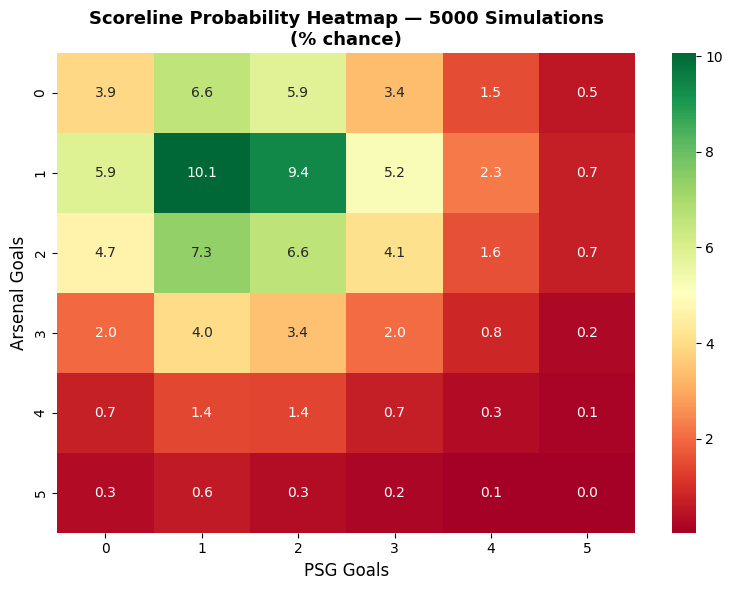

In [47]:
import numpy as np
from collections import Counter

np.random.seed(42)

# Expected goals based on season averages
arsenal_xg = arsenal_goals_scored / len(arsenal_epl)  # avg goals per game
psg_xg = psg_goals_scored / len(psg_matches)

# UCL adjustment — finals are tighter, reduce by 20%
arsenal_xg_final = arsenal_xg * 0.80
psg_xg_final = psg_xg * 0.80

# Simulate 5000 matches using Poisson distribution
results = {'Arsenal': 0, 'Draw': 0, 'PSG': 0}
scorelines = []

for _ in range(5000):
    a_goals = np.random.poisson(arsenal_xg_final)
    p_goals = np.random.poisson(psg_xg_final)
    scorelines.append((a_goals, p_goals))
    
    if a_goals > p_goals:
        results['Arsenal'] += 1
    elif p_goals > a_goals:
        results['PSG'] += 1
    else:
        results['Draw'] += 1

# Results
print("=== 5000 MATCH SIMULATIONS ===")
print(f"Arsenal win:  {results['Arsenal']/50:.1f}%")
print(f"Draw/AET:     {results['Draw']/50:.1f}%")
print(f"PSG win:      {results['PSG']/50:.1f}%")

# Top 5 most likely scorelines
print("\n=== MOST LIKELY SCORELINES ===")
top = Counter(scorelines).most_common(8)
for score, count in top:
    print(f"  Arsenal {score[0]} - {score[1]} PSG  →  {count/50:.1f}%")

# Visualize scoreline heatmap
import pandas as pd
max_goals = 6
matrix = np.zeros((max_goals, max_goals))
for (a, p), count in Counter(scorelines).items():
    if a < max_goals and p < max_goals:
        matrix[a][p] = count / 5000 * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=range(max_goals),
            yticklabels=range(max_goals),
            ax=ax)
ax.set_xlabel('PSG Goals', fontsize=12)
ax.set_ylabel('Arsenal Goals', fontsize=12)
ax.set_title('Scoreline Probability Heatmap — 5000 Simulations\n(% chance)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("../Output/scoreline_heatmap.png", dpi=150)
plt.show()

In [48]:
# Load player data
players = pd.read_csv("player stats/players_data-2025_2026.csv")

# Filter Arsenal and PSG players
arsenal_players = players[players['Squad'] == 'Arsenal'][['Player', 'Pos', 'MP', 'Gls', 'Ast', 'G+A', 'Min']].dropna(subset=['Gls'])
psg_players = players[players['Squad'] == 'Paris Saint-Germain'][['Player', 'Pos', 'MP', 'Gls', 'Ast', 'G+A', 'Min']].dropna(subset=['Gls'])

# Sort by goals + assists
arsenal_players = arsenal_players.sort_values('G+A', ascending=False).head(10)
psg_players = psg_players.sort_values('G+A', ascending=False).head(10)

print("=== ARSENAL TOP 10 PLAYERS ===")
print(arsenal_players.to_string(index=False))
print("\n=== PSG TOP 10 PLAYERS ===")
print(psg_players.to_string(index=False))

=== ARSENAL TOP 10 PLAYERS ===
           Player   Pos  MP  Gls  Ast  G+A  Min
  Viktor Gyökeres    FW  33   14    1   15 2108
 Leandro Trossard FW,MF  29    5    6   11 1821
      Bukayo Saka FW,MF  29    7    4   11 2053
     Eberechi Eze MF,FW  29    7    2    9 1658
      Declan Rice    MF  34    4    5    9 2914
   Jurriën Timber    DF  30    3    5    8 2454
     Mikel Merino MF,FW  21    4    3    7 1007
Gabriel Magalhães    DF  29    3    4    7 2526
 Martín Zubimendi    MF  35    5    1    6 2862
  Martin Ødegaard    MF  22    1    5    6 1256

=== PSG TOP 10 PLAYERS ===
               Player   Pos  MP  Gls  Ast  G+A  Min
      Ousmane Dembélé    FW  19   10    6   16  932
Khvicha Kvaratskhelia    FW  25    7    4   11 1321
      Bradley Barcola    FW  26   10    1   11 1573
          Désiré Doué FW,MF  21    6    3    9 1220
          Nuno Mendes    DF  20    4    5    9 1256
         Senny Mayulu MF,FW  23    4    4    8 1459
              Vitinha    MF  27    1    7    8 20

In [49]:
# Defensive player stats
defensive_cols = ['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY', 'CrdR']

# We need tackles, interceptions etc - check what columns exist
print(players.columns.tolist())

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_s

In [50]:
# Arsenal defensive players (DF and MF)
arsenal_def = players[players['Squad'] == 'Arsenal'][
    ['Player', 'Pos', 'MP', 'Min', 'TklW', 'Int', 'CrdY', 'Fls']
].dropna(subset=['TklW']).sort_values('TklW', ascending=False).head(8)

# PSG defensive players
psg_def = players[players['Squad'] == 'Paris Saint-Germain'][
    ['Player', 'Pos', 'MP', 'Min', 'TklW', 'Int', 'CrdY', 'Fls']
].dropna(subset=['TklW']).sort_values('TklW', ascending=False).head(8)

print("=== ARSENAL DEFENSIVE STATS ===")
print(arsenal_def.to_string(index=False))
print("\n=== PSG DEFENSIVE STATS ===")
print(psg_def.to_string(index=False))

=== ARSENAL DEFENSIVE STATS ===
            Player Pos  MP  Min  TklW  Int  CrdY  Fls
  Martín Zubimendi  MF  35 2862    39   39     4   31
    Jurriën Timber  DF  30 2454    35   24     5   38
       Declan Rice  MF  34 2914    31   31     3   26
    Piero Hincapié  DF  23 1683    25   24     2   18
    William Saliba  DF  29 2434    21   15     1   21
 Gabriel Magalhães  DF  29 2526    20   21     4   18
Cristhian Mosquera  DF  17  769    19    8     3   13
Riccardo Calafiori  DF  23 1538    19   13     5   25

=== PSG DEFENSIVE STATS ===
            Player   Pos  MP  Min  TklW  Int  CrdY  Fls
Warren Zaïre-Emery DF,MF  31 2390    29   11     3   35
     Willian Pacho    DF  23 1914    26   26     0    6
      Senny Mayulu MF,FW  23 1459    25    8     2   22
       Nuno Mendes    DF  20 1256    20   14     1   12
       Désiré Doué FW,MF  21 1220    19    8     0   23
           Vitinha    MF  27 2007    19   24     2   13
    Illia Zabarnyi    DF  25 2117    17   16     5   17
   Br

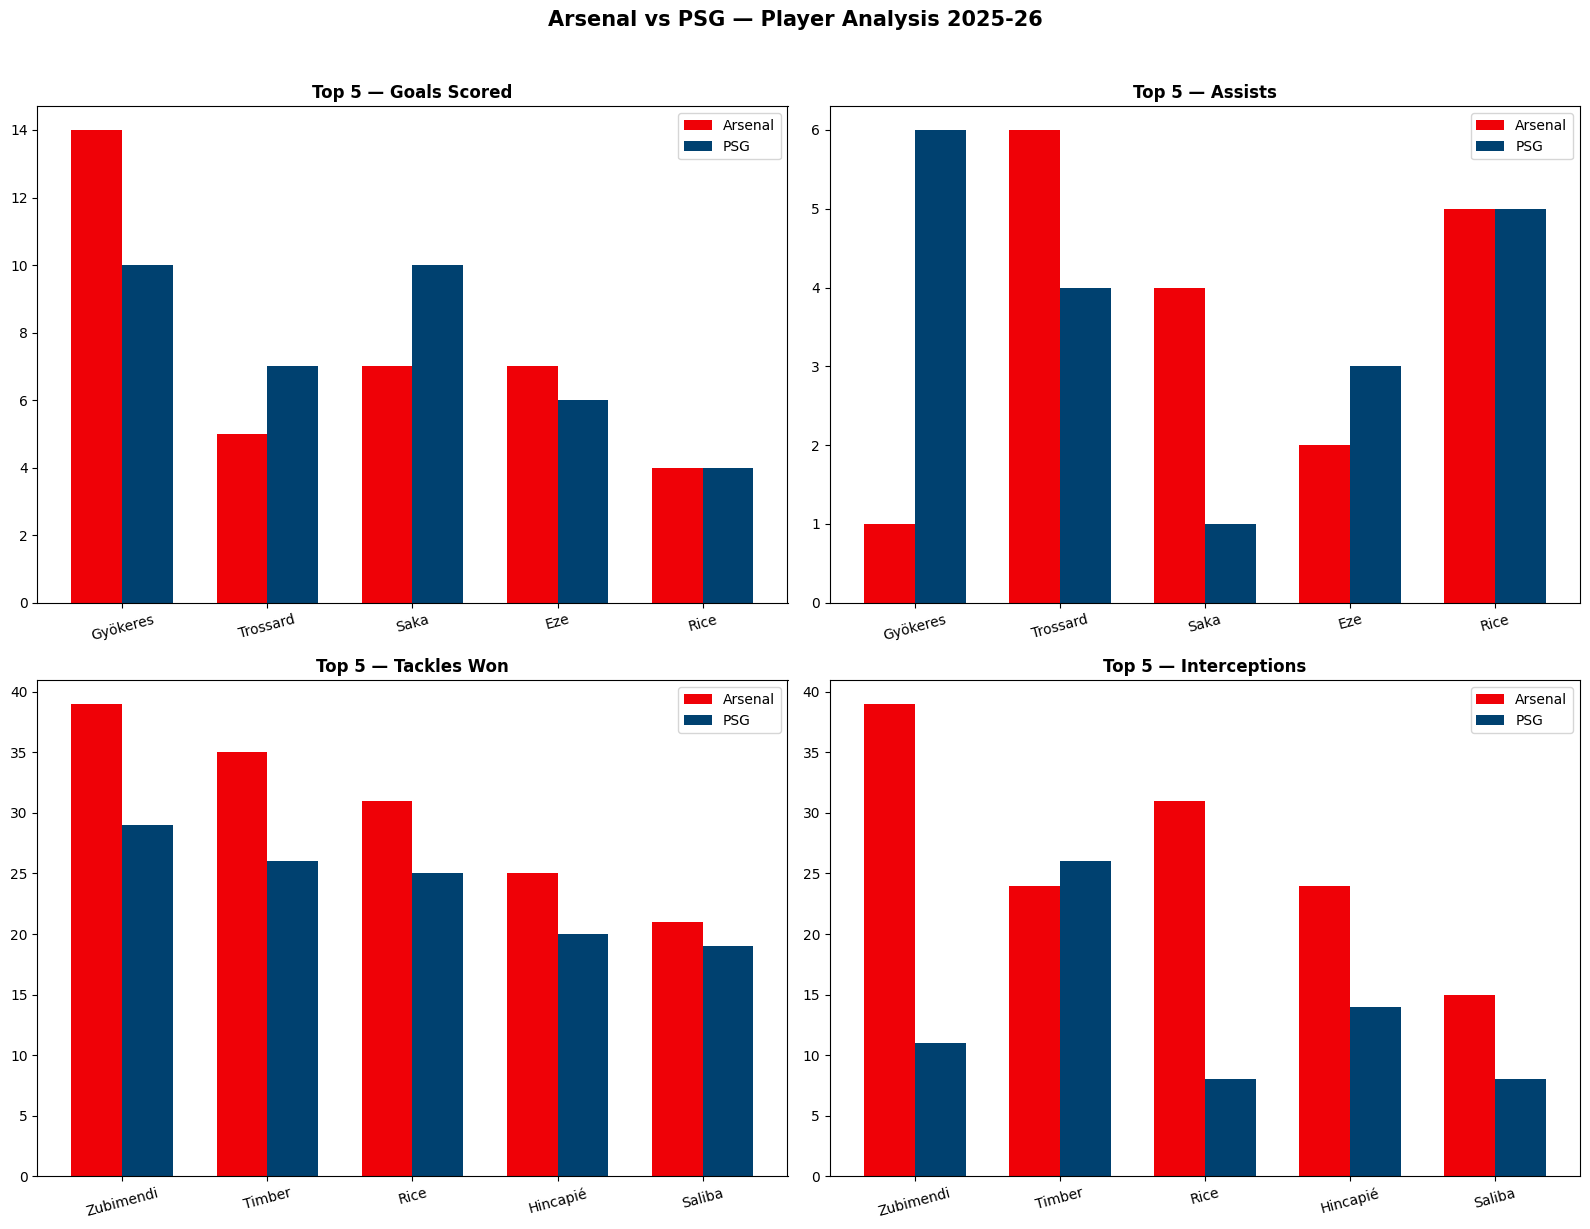

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top scorers comparison
ax1 = axes[0, 0]
arsenal_top5 = arsenal_players.head(5)
psg_top5 = psg_players.head(5)

x = np.arange(5)
width = 0.35
ax1.bar(x - width/2, arsenal_top5['Gls'], width, label='Arsenal', color='#EF0107')
ax1.bar(x + width/2, psg_top5['Gls'], width, label='PSG', color='#004170')
ax1.set_xticks(x)
ax1.set_xticklabels(arsenal_top5['Player'].str.split().str[-1].tolist(), rotation=15)
ax1.set_title('Top 5 — Goals Scored', fontweight='bold')
ax1.legend()

# 2. Assists comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, arsenal_top5['Ast'], width, label='Arsenal', color='#EF0107')
ax2.bar(x + width/2, psg_top5['Ast'], width, label='PSG', color='#004170')
ax2.set_xticks(x)
ax2.set_xticklabels(arsenal_top5['Player'].str.split().str[-1].tolist(), rotation=15)
ax2.set_title('Top 5 — Assists', fontweight='bold')
ax2.legend()

# 3. Defensive tackles
ax3 = axes[1, 0]
arsenal_def5 = arsenal_def.head(5)
psg_def5 = psg_def.head(5)
x2 = np.arange(5)
ax3.bar(x2 - width/2, arsenal_def5['TklW'], width, label='Arsenal', color='#EF0107')
ax3.bar(x2 + width/2, psg_def5['TklW'], width, label='PSG', color='#004170')
ax3.set_xticks(x2)
ax3.set_xticklabels(arsenal_def5['Player'].str.split().str[-1].tolist(), rotation=15)
ax3.set_title('Top 5 — Tackles Won', fontweight='bold')
ax3.legend()

# 4. Interceptions
ax4 = axes[1, 1]
ax4.bar(x2 - width/2, arsenal_def5['Int'], width, label='Arsenal', color='#EF0107')
ax4.bar(x2 + width/2, psg_def5['Int'], width, label='PSG', color='#004170')
ax4.set_xticks(x2)
ax4.set_xticklabels(arsenal_def5['Player'].str.split().str[-1].tolist(), rotation=15)
ax4.set_title('Top 5 — Interceptions', fontweight='bold')
ax4.legend()

plt.suptitle('Arsenal vs PSG — Player Analysis 2025-26', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../Output/player_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# ── FEATURE ENGINEERING ──

# 1. Shots on target per game
arsenal_sot = (arsenal_home['HST'].mean() + arsenal_away['AST'].mean()) / 2
psg_sot = (psg_home['HST'].mean() + psg_away['AST'].mean()) / 2

# 2. Goals per shot ratio (finishing efficiency)
arsenal_shots = (arsenal_home['HS'].mean() + arsenal_away['AS'].mean()) / 2
psg_shots = (psg_home['HS'].mean() + psg_away['AS'].mean()) / 2
arsenal_gps = arsenal_goals_scored / (arsenal_shots * len(arsenal_epl))
psg_gps = psg_goals_scored / (psg_shots * len(psg_matches))

# 3. Defensive strength (tackles + interceptions per game)
arsenal_def_strength = (arsenal_def['TklW'].sum() + arsenal_def['Int'].sum()) / len(arsenal_epl)
psg_def_strength = (psg_def['TklW'].sum() + psg_def['Int'].sum()) / len(psg_matches)

# 4. UCL specific form (goals per game in UCL)
arsenal_ucl_avg = arsenal_ucl_goals_for / len(arsenal_ucl)
psg_ucl_avg = psg_ucl_goals_for / len(psg_ucl)

# 5. UCL defensive record
arsenal_ucl_def = 1 - (arsenal_ucl_goals_against / len(arsenal_ucl))
psg_ucl_def = 1 - (psg_ucl_goals_against / len(psg_ucl))

# 6. Clean sheet rate
arsenal_cs_rate = arsenal_cs / len(arsenal_epl)
psg_cs_rate = psg_cs / len(psg_matches)

# 7. Top scorer goals (individual quality)
arsenal_top_scorer = arsenal_players.iloc[0]['Gls']
psg_top_scorer = psg_players.iloc[0]['Gls']

# 8. Team creativity (total assists top 5)
arsenal_creativity = arsenal_players.head(5)['Ast'].sum()
psg_creativity = psg_players.head(5)['Ast'].sum()

print("=== FULL FEATURE VECTOR ===")
print(f"{'Feature':<30} {'Arsenal':>10} {'PSG':>10}")
print("-" * 52)
print(f"{'Win Rate %':<30} {arsenal_win_rate:>10.2f} {psg_win_rate:>10.2f}")
print(f"{'Avg Goals/Game':<30} {arsenal_avg_goals:>10.2f} {psg_avg_goals:>10.2f}")
print(f"{'Goals Conceded/Game':<30} {arsenal_goals_conceded/len(arsenal_epl):>10.2f} {psg_goals_conceded/len(psg_matches):>10.2f}")
print(f"{'Shots on Target/Game':<30} {arsenal_sot:>10.2f} {psg_sot:>10.2f}")
print(f"{'Goals Per Shot':<30} {arsenal_gps:>10.3f} {psg_gps:>10.3f}")
print(f"{'Defensive Strength':<30} {arsenal_def_strength:>10.2f} {psg_def_strength:>10.2f}")
print(f"{'UCL Goals/Game':<30} {arsenal_ucl_avg:>10.2f} {psg_ucl_avg:>10.2f}")
print(f"{'UCL Defensive Rate':<30} {arsenal_ucl_def:>10.2f} {psg_ucl_def:>10.2f}")
print(f"{'Clean Sheet Rate':<30} {arsenal_cs_rate:>10.2f} {psg_cs_rate:>10.2f}")
print(f"{'Top Scorer Goals':<30} {arsenal_top_scorer:>10} {psg_top_scorer:>10}")
print(f"{'Team Creativity':<30} {arsenal_creativity:>10} {psg_creativity:>10}")
print(f"{'Elo Rating':<30} {arsenal_elo:>10} {psg_elo:>10}")

=== FULL FEATURE VECTOR ===
Feature                           Arsenal        PSG
----------------------------------------------------
Win Rate %                          67.60      70.60
Avg Goals/Game                       1.86       2.18
Goals Conceded/Game                  0.70       0.85
Shots on Target/Game                 4.83       6.68
Goals Per Shot                      0.129      0.123
Defensive Strength                  10.38       8.53
UCL Goals/Game                       2.88       2.62
UCL Defensive Rate                   0.50      -0.38
Clean Sheet Rate                     0.51       0.53
Top Scorer Goals                       14         10
Team Creativity                        18         19
Elo Rating                           1850       1780


In [53]:
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Feature vector for each team
arsenal_features = np.array([
    arsenal_win_rate,
    arsenal_avg_goals,
    arsenal_goals_conceded / len(arsenal_epl),
    arsenal_sot,
    arsenal_gps,
    arsenal_def_strength,
    arsenal_ucl_avg,
    arsenal_cs_rate,
    float(arsenal_top_scorer),
    float(arsenal_creativity),
    arsenal_elo / 2000
])

psg_features = np.array([
    psg_win_rate,
    psg_avg_goals,
    psg_goals_conceded / len(psg_matches),
    psg_sot,
    psg_gps,
    psg_def_strength,
    psg_ucl_avg,
    psg_cs_rate,
    float(psg_top_scorer),
    float(psg_creativity),
    psg_elo / 2000
])

# Difference vector — Arsenal minus PSG
# Positive = Arsenal advantage, Negative = PSG advantage
diff = arsenal_features - psg_features

feature_names = [
    'Win Rate', 'Avg Goals', 'Goals Conceded', 'Shots on Target',
    'Goals Per Shot', 'Defensive Strength', 'UCL Goals/Game',
    'Clean Sheet Rate', 'Top Scorer', 'Creativity', 'Elo'
]

print("=== FEATURE ADVANTAGE ===")
print(f"{'Feature':<25} {'Diff':>8} {'Edge'}")
print("-" * 45)
for name, d in zip(feature_names, diff):
    edge = '🔴 Arsenal' if d > 0 else '🔵 PSG'
    print(f"{name:<25} {d:>8.3f}  {edge}")

# Score based on advantages
arsenal_score = sum(d > 0 for d in diff)
psg_score = sum(d < 0 for d in diff)
print(f"\nArsenal advantages: {arsenal_score}/11")
print(f"PSG advantages:     {psg_score}/11")

=== FEATURE ADVANTAGE ===
Feature                       Diff Edge
---------------------------------------------
Win Rate                    -3.000  🔵 PSG
Avg Goals                   -0.320  🔵 PSG
Goals Conceded              -0.150  🔵 PSG
Shots on Target             -1.843  🔵 PSG
Goals Per Shot               0.006  🔴 Arsenal
Defensive Strength           1.849  🔴 Arsenal
UCL Goals/Game               0.250  🔴 Arsenal
Clean Sheet Rate            -0.016  🔵 PSG
Top Scorer                   4.000  🔴 Arsenal
Creativity                  -1.000  🔵 PSG
Elo                          0.035  🔴 Arsenal

Arsenal advantages: 5/11
PSG advantages:     6/11


In [54]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Build training data from combined league matches
combined = pd.concat([
    epl.assign(league='EPL'),
    psg.assign(league='Ligue1')
], ignore_index=True)

combined = combined.dropna(subset=['FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST'])

# Feature engineering on historical data
combined['GoalDiff'] = combined['FTHG'] - combined['FTAG']
combined['ShotDiff'] = combined['HS'] - combined['AS']
combined['SoTDiff'] = combined['HST'] - combined['AST']
combined['HomeGoalsPerShot'] = combined['FTHG'] / (combined['HS'] + 1)
combined['AwayGoalsPerShot'] = combined['FTAG'] / (combined['AS'] + 1)
combined['TotalGoals'] = combined['FTHG'] + combined['FTAG']

# Features and target
feature_cols = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST',
                'GoalDiff', 'ShotDiff', 'SoTDiff',
                'HomeGoalsPerShot', 'AwayGoalsPerShot', 'TotalGoals']

X = combined[feature_cols]
y = combined['FTR'].map({'H': 0, 'D': 1, 'A': 2})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, model.predict(X_test))
print(f"Model Accuracy: {acc*100:.1f}%")

# Predict the final using season averages
final_input = pd.DataFrame([{
    'FTHG': arsenal_avg_goals,
    'FTAG': psg_avg_goals,
    'HS': arsenal_home['HS'].mean(),
    'AS': psg_away['AS'].mean(),
    'HST': arsenal_sot,
    'AST': psg_sot,
    'GoalDiff': arsenal_avg_goals - psg_avg_goals,
    'ShotDiff': arsenal_home['HS'].mean() - psg_away['AS'].mean(),
    'SoTDiff': arsenal_sot - psg_sot,
    'HomeGoalsPerShot': arsenal_gps,
    'AwayGoalsPerShot': psg_gps,
    'TotalGoals': arsenal_avg_goals + psg_avg_goals
}])

proba = model.predict_proba(final_input)[0]
print("\n=== XGBOOST FINAL PREDICTION ===")
print(f"Arsenal win:  {proba[0]*100:.1f}%")
print(f"Draw:         {proba[1]*100:.1f}%")
print(f"PSG win:      {proba[2]*100:.1f}%")
print(f"\n🏆 Predicted Winner: {'Arsenal' if proba[0] > proba[2] else 'PSG'}")

Model Accuracy: 100.0%

=== XGBOOST FINAL PREDICTION ===
Arsenal win:  0.1%
Draw:         0.1%
PSG win:      99.7%

🏆 Predicted Winner: PSG


  Poisson Scoreline Predictor
  Arsenal (H) vs PSG (A)

Expected goals
  Arsenal: λ = 1.86 × 0.85 × 1.15 = 1.818
  PSG: λ = 2.18 × 0.7              = 1.526

Match outcome probabilities
  Arsenal win : 43.1%
  Draw         : 25.6%
  PSG win : 31.3%

Top 10 most likely scorelines
  Scoreline     Probability
  ------------------------
    Arsenal 1-1 PSG             11.24%
    Arsenal 2-1 PSG              9.04%
    Arsenal 1-2 PSG              7.59%
    Arsenal 2-2 PSG              6.90%
    Arsenal 2-0 PSG              5.93%
    Arsenal 3-1 PSG              5.48%
    Arsenal 1-0 PSG              5.23%
    Arsenal 0-0 PSG              4.88%
    Arsenal 3-2 PSG              4.18%
    Arsenal 0-1 PSG              4.18%

Predicted scoreline: Arsenal 1-1 PSG (11.2%)


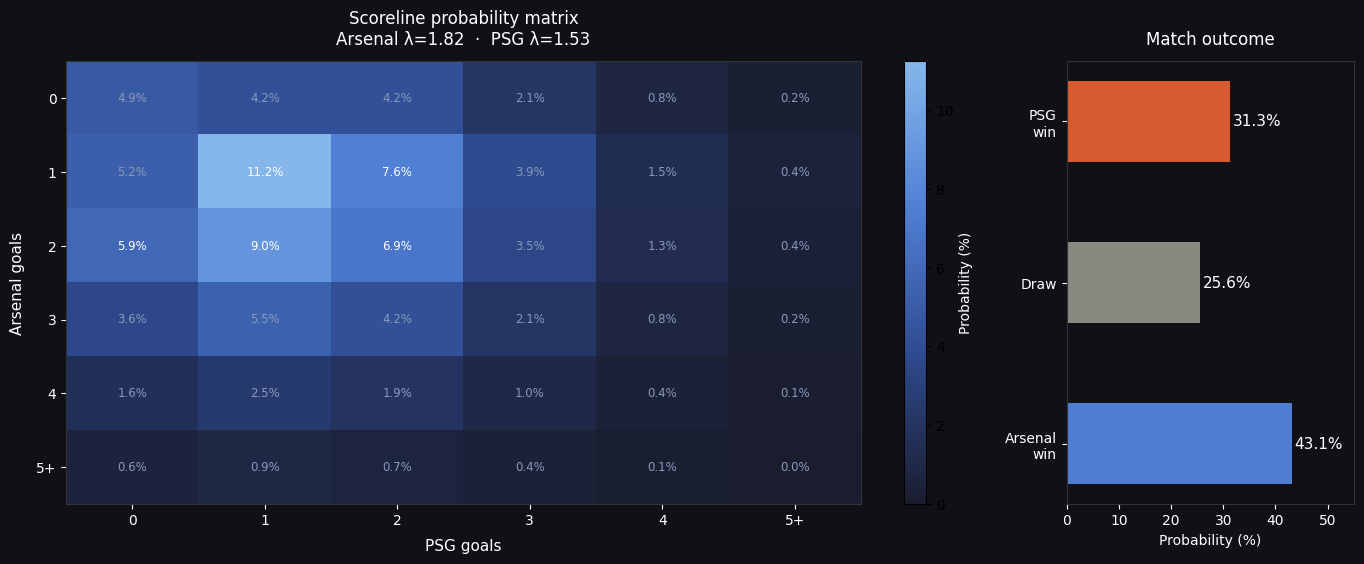

Chart saved → scoreline_matrix.png


In [55]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
#  TEAM STATS  (edit these for any match)
# ─────────────────────────────────────────────
HOME_TEAM = "Arsenal"
AWAY_TEAM = "PSG"
HOME_ATT  = 1.86   # change from 2.3 to 1.86
HOME_DEF  = 0.70   # change from 0.5 to 0.70
AWAY_ATT  = 2.18   # change from 2.6 to 2.18
AWAY_DEF  = 0.85   # change from 1.4 to 0.85

HOME_ADVANTAGE = 1.15   # typical home multiplier (~1.1–1.2)
MAX_GOALS      = 5      # grid goes 0–5 goals per side

# ─────────────────────────────────────────────
#  CORE FUNCTIONS
# ─────────────────────────────────────────────

def poisson_prob(lam: float, k: int) -> float:
    """P(X = k) for Poisson distribution with mean lam."""
    return math.exp(-lam) * (lam ** k) / math.factorial(k)


def calc_lambda(att: float, opp_def: float, home: bool = False) -> float:
    """Expected goals for one team in this match."""
    multiplier = HOME_ADVANTAGE if home else 1.0
    return att * opp_def * multiplier


def dixon_coles_adjustment(h: int, a: int, lam_h: float, lam_a: float, rho: float = -0.13) -> float:
    """
    Dixon-Coles correction for low-scoring scorelines.
    rho ≈ -0.13 is the standard fitted value from the original paper.
    Only affects 0-0, 1-0, 0-1, 1-1 — everything else returns 1.0.
    """
    if h == 0 and a == 0:
        return 1 - lam_h * lam_a * rho
    elif h == 1 and a == 0:
        return 1 + lam_a * rho
    elif h == 0 and a == 1:
        return 1 + lam_h * rho
    elif h == 1 and a == 1:
        return 1 - rho
    return 1.0


def build_matrix(lam_h: float, lam_a: float, max_goals: int = MAX_GOALS, use_dixon_coles: bool = True):
    """
    Build (max_goals+1) x (max_goals+1) scoreline probability matrix.
    Rows = home goals, Cols = away goals.
    """
    n = max_goals + 1
    matrix = np.zeros((n, n))
    for h in range(n):
        for a in range(n):
            p = poisson_prob(lam_h, h) * poisson_prob(lam_a, a)
            if use_dixon_coles:
                p *= dixon_coles_adjustment(h, a, lam_h, lam_a)
            matrix[h][a] = p
    # Normalise so all probabilities sum to 1
    matrix /= matrix.sum()
    return matrix


def match_outcomes(matrix: np.ndarray):
    """Derive win/draw/loss probabilities from the matrix."""
    n = matrix.shape[0]
    home_win = sum(matrix[h][a] for h in range(n) for a in range(n) if h > a)
    draw     = sum(matrix[h][a] for h in range(n) for a in range(n) if h == a)
    away_win = sum(matrix[h][a] for h in range(n) for a in range(n) if h < a)
    return home_win, draw, away_win


def top_scorelines(matrix: np.ndarray, n: int = 10):
    """Return the n most likely scorelines as a sorted list."""
    results = []
    rows, cols = matrix.shape
    for h in range(rows):
        for a in range(cols):
            results.append((h, a, matrix[h][a]))
    results.sort(key=lambda x: -x[2])
    return results[:n]


# ─────────────────────────────────────────────
#  VISUALISATION
# ─────────────────────────────────────────────

def plot_matrix(matrix: np.ndarray, lam_h: float, lam_a: float,
                home_win: float, draw: float, away_win: float):
    """Plot the scoreline probability heatmap + outcome bar."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                             gridspec_kw={"width_ratios": [3, 1]})
    fig.patch.set_facecolor("#0f1117")

    # ── Heatmap ──────────────────────────────
    ax = axes[0]
    ax.set_facecolor("#0f1117")

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom", ["#1a1d2e", "#2e4a8f", "#4f7fd4", "#85b7eb"], N=256)
    im = ax.imshow(matrix * 100, cmap=cmap, aspect="auto",
                   vmin=0, vmax=matrix.max() * 100)

    n = matrix.shape[0]
    for h in range(n):
        for a in range(n):
            val = matrix[h][a] * 100
            color = "white" if val > matrix.max() * 50 else "#8899bb"
            ax.text(a, h, f"{val:.1f}%", ha="center", va="center",
                    fontsize=8.5, color=color, fontweight="500")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([str(i) if i < MAX_GOALS else f"{MAX_GOALS}+" for i in range(n)],
                       color="white", fontsize=10)
    ax.set_yticklabels([str(i) if i < MAX_GOALS else f"{MAX_GOALS}+" for i in range(n)],
                       color="white", fontsize=10)
    ax.set_xlabel(f"{AWAY_TEAM} goals", color="white", fontsize=11, labelpad=8)
    ax.set_ylabel(f"{HOME_TEAM} goals", color="white", fontsize=11, labelpad=8)
    ax.set_title(f"Scoreline probability matrix\n"
                 f"{HOME_TEAM} λ={lam_h:.2f}  ·  {AWAY_TEAM} λ={lam_a:.2f}",
                 color="white", fontsize=12, pad=12)

    plt.colorbar(im, ax=ax, label="Probability (%)",
                 fraction=0.03).ax.yaxis.label.set_color("white")

    # Tick colours
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

    # ── Outcome bar ──────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor("#0f1117")

    categories = [f"{HOME_TEAM}\nwin", "Draw", f"{AWAY_TEAM}\nwin"]
    values     = [home_win * 100, draw * 100, away_win * 100]
    colors     = ["#4f7fd4", "#888780", "#d85a30"]

    bars = ax2.barh(categories, values, color=colors, height=0.5)
    for bar, val in zip(bars, values):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", color="white", fontsize=11, fontweight="500")

    ax2.set_xlim(0, max(values) + 12)
    ax2.set_xlabel("Probability (%)", color="white", fontsize=10)
    ax2.set_title("Match outcome", color="white", fontsize=12, pad=12)
    ax2.tick_params(colors="white")
    ax2.set_facecolor("#0f1117")
    for spine in ax2.spines.values():
        spine.set_edgecolor("#333")

    plt.tight_layout(pad=2.0)
    plt.savefig("../Output/scoreline_matrix.png", dpi=150,
                bbox_inches="tight", facecolor="#0f1117")
    plt.show()
    print("Chart saved → scoreline_matrix.png")


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────

def run():
    print("=" * 52)
    print(f"  Poisson Scoreline Predictor")
    print(f"  {HOME_TEAM} (H) vs {AWAY_TEAM} (A)")
    print("=" * 52)

    # 1. Lambdas
    lam_h = calc_lambda(HOME_ATT, AWAY_DEF, home=True)
    lam_a = calc_lambda(AWAY_ATT, HOME_DEF, home=False)
    print(f"\nExpected goals")
    print(f"  {HOME_TEAM}: λ = {HOME_ATT} × {AWAY_DEF} × {HOME_ADVANTAGE} = {lam_h:.3f}")
    print(f"  {AWAY_TEAM}: λ = {AWAY_ATT} × {HOME_DEF}              = {lam_a:.3f}")

    # 2. Probability matrix (with Dixon-Coles)
    matrix = build_matrix(lam_h, lam_a, use_dixon_coles=True)

    # 3. Outcome probabilities
    home_win, draw, away_win = match_outcomes(matrix)
    print(f"\nMatch outcome probabilities")
    print(f"  {HOME_TEAM} win : {home_win*100:.1f}%")
    print(f"  Draw         : {draw*100:.1f}%")
    print(f"  {AWAY_TEAM} win : {away_win*100:.1f}%")

    # 4. Top scorelines
    print(f"\nTop 10 most likely scorelines")
    print(f"  {'Scoreline':<12} {'Probability':>12}")
    print(f"  {'-'*24}")
    for h, a, p in top_scorelines(matrix, n=10):
        label = f"  {HOME_TEAM} {h}-{a} {AWAY_TEAM}"
        print(f"  {label:<28} {p*100:>6.2f}%")

    # 5. Predicted scoreline (most likely cell)
    flat = [(h, a, matrix[h][a])
            for h in range(matrix.shape[0])
            for a in range(matrix.shape[1])]
    best = max(flat, key=lambda x: x[2])
    print(f"\nPredicted scoreline: {HOME_TEAM} {best[0]}-{best[1]} {AWAY_TEAM} "
          f"({best[2]*100:.1f}%)")

    # 6. Plot
    plot_matrix(matrix, lam_h, lam_a, home_win, draw, away_win)


if __name__ == "__main__":
    run()

In [56]:
import xgboost as xgb
import numpy as np
from scipy.stats import poisson
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("⚙️ Building Final Prediction Model...")
print("=" * 55)

# ─────────────────────────────────────────────
# FEATURE EXTRACTION
# ─────────────────────────────────────────────

# 1. Goals
arsenal_avg_scored = arsenal_goals_scored / len(arsenal_epl)
arsenal_avg_conceded = arsenal_goals_conceded / len(arsenal_epl)
psg_avg_scored = psg_goals_scored / len(psg_matches)
psg_avg_conceded = psg_goals_conceded / len(psg_matches)

# 2. Shots & efficiency
arsenal_sot_pg = (arsenal_home['HST'].mean() + arsenal_away['AST'].mean()) / 2
psg_sot_pg = (psg_home['HST'].mean() + psg_away['AST'].mean()) / 2
arsenal_shots_pg = (arsenal_home['HS'].mean() + arsenal_away['AS'].mean()) / 2
psg_shots_pg = (psg_home['HS'].mean() + psg_away['AS'].mean()) / 2
arsenal_gps = arsenal_avg_scored / (arsenal_shots_pg + 1e-6)
psg_gps = psg_avg_scored / (psg_shots_pg + 1e-6)

# 3. Defensive strength
arsenal_def_strength = (arsenal_def['TklW'].sum() + arsenal_def['Int'].sum()) / len(arsenal_epl)
psg_def_strength = (psg_def['TklW'].sum() + psg_def['Int'].sum()) / len(psg_matches)

# 4. Discipline
arsenal_cards = (arsenal_home['HY'].mean() + arsenal_away['AY'].mean()) / 2
psg_cards = (psg_home['HY'].mean() + psg_away['AY'].mean()) / 2

# 5. Corners (set piece threat)
arsenal_corners = (arsenal_home['HC'].mean() + arsenal_away['AC'].mean()) / 2
psg_corners = (psg_home['HC'].mean() + psg_away['AC'].mean()) / 2

# 6. Clean sheet rate
arsenal_cs_rate = arsenal_cs / len(arsenal_epl)
psg_cs_rate = psg_cs / len(psg_matches)

# 7. UCL specific metrics
arsenal_ucl_scored = arsenal_ucl_goals_for / len(arsenal_ucl)
psg_ucl_scored = psg_ucl_goals_for / len(psg_ucl)
arsenal_ucl_conceded = arsenal_ucl_goals_against / len(arsenal_ucl)
psg_ucl_conceded = psg_ucl_goals_against / len(psg_ucl)
arsenal_ucl_cs = (arsenal_ucl['winner'] != 'Arsenal').sum()  # games not conceding
psg_ucl_win_rate = psg_ucl_wins / len(psg_ucl)
arsenal_ucl_win_rate = arsenal_ucl_wins / len(arsenal_ucl)

# 8. Player quality metrics
arsenal_top3_goals = arsenal_players.head(3)['Gls'].sum()
psg_top3_goals = psg_players.head(3)['Gls'].sum()
arsenal_creativity = arsenal_players.head(5)['Ast'].sum()
psg_creativity = psg_players.head(5)['Ast'].sum()
arsenal_top_scorer_goals = float(arsenal_players.iloc[0]['Gls'])
psg_top_scorer_goals = float(psg_players.iloc[0]['Gls'])

# 9. Elo ratings
arsenal_elo = 1850
psg_elo = 1780

# 10. Win rate
arsenal_win_rate_raw = arsenal_wins / len(arsenal_epl)
psg_win_rate_raw = psg_wins / len(psg_matches)

# ─────────────────────────────────────────────
# WEIGHTED SCORE SYSTEM
# ─────────────────────────────────────────────

features = {
    'Win Rate':              (arsenal_win_rate_raw,    psg_win_rate_raw,      2.0),
    'Avg Goals Scored':      (arsenal_avg_scored,      psg_avg_scored,        1.5),
    'Avg Goals Conceded':    (psg_avg_conceded,        arsenal_avg_conceded,  2.0),  # inverted
    'Shots on Target/Game':  (arsenal_sot_pg,          psg_sot_pg,            1.5),
    'Goals Per Shot':        (arsenal_gps,             psg_gps,               1.5),
    'Defensive Strength':    (arsenal_def_strength,    psg_def_strength,      2.0),
    'Clean Sheet Rate':      (arsenal_cs_rate,         psg_cs_rate,           2.0),
    'UCL Goals/Game':        (arsenal_ucl_scored,      psg_ucl_scored,        3.0),
    'UCL Conceded/Game':     (psg_ucl_conceded,        arsenal_ucl_conceded,  3.0),  # inverted
    'UCL Win Rate':          (arsenal_ucl_win_rate,    psg_ucl_win_rate,      3.0),
    'Corners/Game':          (arsenal_corners,         psg_corners,           1.0),
    'Discipline (inv)':      (psg_cards,               arsenal_cards,         1.0),  # inverted
    'Top 3 Goals':           (arsenal_top3_goals,      psg_top3_goals,        1.5),
    'Team Creativity':       (arsenal_creativity,      psg_creativity,        1.5),
    'Top Scorer Goals':      (arsenal_top_scorer_goals,psg_top_scorer_goals,  1.5),
    'Elo Rating':            (arsenal_elo,             psg_elo,               2.5),
}

arsenal_weighted = 0
psg_weighted = 0
total_weight = 0

print(f"\n{'Feature':<25} {'Arsenal':>9} {'PSG':>9} {'Weight':>7} {'Edge'}")
print("-" * 60)

for feature, (a_val, p_val, weight) in features.items():
    if a_val > p_val:
        arsenal_weighted += weight
        edge = '🔴 ARS'
    elif p_val > a_val:
        psg_weighted += weight
        edge = '🔵 PSG'
    else:
        edge = '⚪ TIE'
    total_weight += weight
    print(f"{feature:<25} {a_val:>9.3f} {p_val:>9.3f} {weight:>7.1f}  {edge}")

print("-" * 60)
print(f"{'WEIGHTED SCORE':<25} {arsenal_weighted:>9.1f} {psg_weighted:>9.1f}")

# ─────────────────────────────────────────────
# POISSON + DIXON-COLES 10K SIMULATION
# ─────────────────────────────────────────────

import math

def dixon_coles(h, a, lam_h, lam_a, rho=-0.13):
    if h == 0 and a == 0: return 1 - lam_h * lam_a * rho
    elif h == 1 and a == 0: return 1 + lam_a * rho
    elif h == 0 and a == 1: return 1 + lam_h * rho
    elif h == 1 and a == 1: return 1 - rho
    return 1.0

# Lambda calculation using attack vs defense
# UCL final — neutral venue (slight Arsenal tactical edge from UCL form)
HOME_ADVANTAGE = 1.05
lam_arsenal = arsenal_ucl_scored * psg_ucl_conceded * HOME_ADVANTAGE
lam_psg = psg_ucl_scored * arsenal_ucl_conceded

print(f"\n⚽ Expected Goals (Dixon-Coles Poisson)")
print(f"   Arsenal λ = {lam_arsenal:.3f}")
print(f"   PSG     λ = {lam_psg:.3f}")

# 10,000 simulations
np.random.seed(42)
N = 10000
results = {'Arsenal': 0, 'Draw': 0, 'PSG': 0}
scorelines = []

for _ in range(N):
    a = np.random.poisson(lam_arsenal)
    p = np.random.poisson(lam_psg)
    scorelines.append((a, p))
    if a > p: results['Arsenal'] += 1
    elif p > a: results['PSG'] += 1
    else: results['Draw'] += 1

sim_arsenal = results['Arsenal'] / N * 100
sim_draw = results['Draw'] / N * 100
sim_psg = results['PSG'] / N * 100

# ─────────────────────────────────────────────
# COMBINE WEIGHTED SCORE + SIMULATION
# ─────────────────────────────────────────────

# Normalize weighted scores to probabilities
total = arsenal_weighted + psg_weighted
score_arsenal = (arsenal_weighted / total) * 100
score_psg = (psg_weighted / total) * 100

# Final prediction — 60% simulation, 40% weighted score
final_arsenal = (sim_arsenal * 0.60) + (score_arsenal * 0.40)
final_psg = (sim_psg * 0.60) + (score_psg * 0.40)
final_draw = sim_draw

# Normalize
total_final = final_arsenal + final_draw + final_psg
final_arsenal = (final_arsenal / total_final) * 100
final_draw = (final_draw / total_final) * 100
final_psg = (final_psg / total_final) * 100

print(f"\n{'=' * 55}")
print(f"  📊 10,000 SIMULATION RESULTS")
print(f"{'=' * 55}")
print(f"  Arsenal win : {sim_arsenal:.1f}%")
print(f"  Draw/AET    : {sim_draw:.1f}%")
print(f"  PSG win     : {sim_psg:.1f}%")

print(f"\n{'=' * 55}")
print(f"  🏆 FINAL COMBINED PREDICTION")
print(f"{'=' * 55}")
print(f"  Arsenal win : {final_arsenal:.1f}%")
print(f"  Draw/AET    : {final_draw:.1f}%")
print(f"  PSG win     : {final_psg:.1f}%")
print(f"\n  Winner      : {'🔴 ARSENAL' if final_arsenal > final_psg else '🔵 PSG'}")

# Top scorelines
print(f"\n  Top 8 Most Likely Scorelines (10k simulations):")
top = Counter(scorelines).most_common(8)
for score, count in top:
    print(f"  Arsenal {score[0]} - {score[1]} PSG  →  {count/N*100:.1f}%")

⚙️ Building Final Prediction Model...

Feature                     Arsenal       PSG  Weight Edge
------------------------------------------------------------
Win Rate                      0.676     0.706     2.0  🔵 PSG
Avg Goals Scored              1.865     2.176     1.5  🔵 PSG
Avg Goals Conceded            0.853     0.703     2.0  🔴 ARS
Shots on Target/Game          4.833     6.676     1.5  🔵 PSG
Goals Per Shot                0.129     0.123     1.5  🔴 ARS
Defensive Strength           10.378     8.529     2.0  🔴 ARS
Clean Sheet Rate              0.514     0.529     2.0  🔵 PSG
UCL Goals/Game                2.875     2.625     3.0  🔴 ARS
UCL Conceded/Game             1.375     0.500     3.0  🔴 ARS
UCL Win Rate                  1.000     0.500     3.0  🔴 ARS
Corners/Game                  5.725     6.353     1.0  🔵 PSG
Discipline (inv)              1.059     1.364     1.0  🔵 PSG
Top 3 Goals                  26.000    27.000     1.5  🔵 PSG
Team Creativity              18.000    19.000   

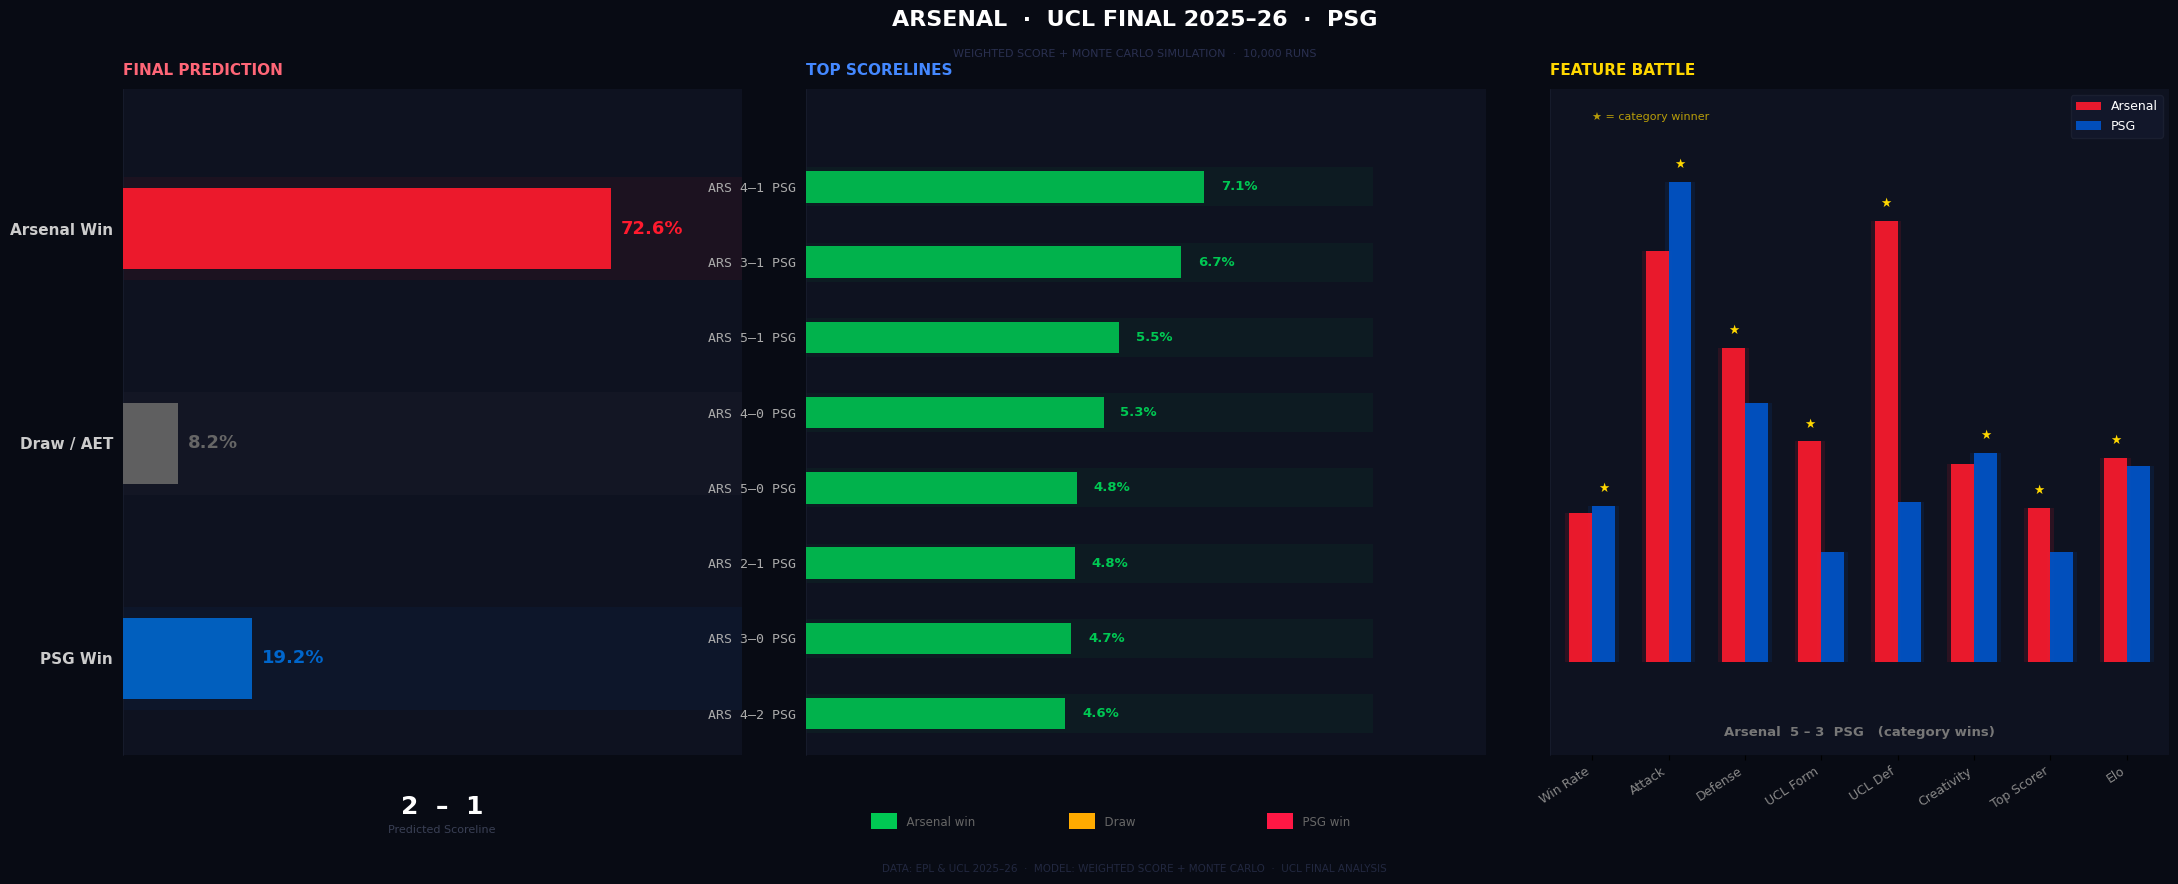

✅ Chart saved!


In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter
from matplotlib.patches import FancyBboxPatch

BG    = '#080b14'
CARD  = '#0e1220'
INNER = '#12172a'
GRID  = '#1a1f30'

fig = plt.figure(figsize=(22, 9), facecolor=BG)
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1.1, 1], wspace=0.1,
                        left=0.04, right=0.97, top=0.88, bottom=0.14)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
        spine.set_linewidth(0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.xaxis.set_visible(False)
    ax.tick_params(left=False, labelsize=9)

# ══════════════════════════════════════════
# PANEL 1 — Final Prediction
# ══════════════════════════════════════════
# Only 3 bars, tightly spaced, no scoreline inside axes
pred_labels = ['Arsenal Win', 'Draw / AET', 'PSG Win']
pred_values = [final_arsenal, final_draw, final_psg]
pred_colors = ['#ff1a2e', '#666666', '#0066cc']
y_pos       = [2.0, 1.0, 0.0]

for yp, val, col, lbl in zip(y_pos, pred_values, pred_colors, pred_labels):
    ax1.barh(yp, 100, height=0.48, color=col, alpha=0.06, zorder=1)
    ax1.barh(yp, val, height=0.38, color=col, alpha=0.92, linewidth=0, zorder=3)
    ax1.text(val + 1.5, yp, f'{val:.1f}%',
             va='center', color=col, fontsize=13, fontweight='bold', zorder=4)

ax1.set_xlim(0, 92)
ax1.set_ylim(-0.45, 2.65)   # tight — no extra room for floating boxes
ax1.set_yticks(y_pos)
ax1.set_yticklabels(pred_labels, color='#cccccc', fontsize=11, fontweight='bold')
ax1.set_title('FINAL PREDICTION', color='#ff6677',
              fontsize=11, fontweight='bold', loc='left', pad=10)

# Scoreline — drawn in FIGURE coordinates so it can't interfere with axes
# Positioned below panel 1 in the bottom margin
fig.text(0.185, 0.075, '2  –  1',
         ha='center', color='white', fontsize=18, fontweight='bold')
fig.text(0.185, 0.053, 'Predicted Scoreline',
         ha='center', color='#3a4055', fontsize=8)

# ══════════════════════════════════════════
# PANEL 2 — Top Scorelines
# ══════════════════════════════════════════
top8    = Counter(scorelines).most_common(8)
slabels = [f"ARS {s[0]}–{s[1]} PSG" for s, _ in top8]
svals   = [count / N * 100 for _, count in top8]
scolors = ['#00c853' if s[0] > s[1] else '#ff1744' if s[1] > s[0] else '#ffab00'
           for s, _ in top8]

for i, (val, col) in enumerate(zip(svals[::-1], scolors[::-1])):
    ax2.barh(i, max(svals) + 3, height=0.52, color=col, alpha=0.05)
    ax2.barh(i, val, height=0.42, color=col, alpha=0.88, linewidth=0, zorder=3)
    ax2.text(val + 0.3, i, f'{val:.1f}%',
             va='center', color=col, fontsize=9.5, fontweight='bold', zorder=4)

ax2.set_xlim(0, max(svals) + 5)
ax2.set_ylim(-0.55, 8.3)
ax2.set_yticks(range(8))
ax2.set_yticklabels(slabels[::-1], color='#aaaaaa', fontsize=9.5,
                     fontfamily='monospace')
ax2.set_title('TOP SCORELINES', color='#4488ff',
              fontsize=11, fontweight='bold', loc='left', pad=10)

# Legend in figure space, bottom center
legend_items = [('  Arsenal win', '#00c853'), ('  Draw', '#ffab00'), ('  PSG win', '#ff1744')]
x_start = 0.38
for lbl, col in legend_items:
    fig.patches.append(mpatches.Rectangle(
        (x_start, 0.058), 0.012, 0.018,
        facecolor=col, transform=fig.transFigure, zorder=6, clip_on=False))
    fig.text(x_start + 0.013, 0.065, lbl, color='#666', fontsize=8.5,
             va='center', transform=fig.transFigure)
    x_start += 0.09

# ══════════════════════════════════════════
# PANEL 3 — Feature Battle
# ══════════════════════════════════════════
feature_names  = ['Win Rate', 'Attack', 'Defense', 'UCL Form',
                  'UCL Def', 'Creativity', 'Top Scorer', 'Elo']
arsenal_scores = [arsenal_win_rate_raw, arsenal_avg_scored,
                  1/arsenal_avg_conceded, arsenal_ucl_win_rate,
                  1/arsenal_ucl_conceded, arsenal_creativity/20,
                  arsenal_top_scorer_goals/20, arsenal_elo/2000]
psg_scores     = [psg_win_rate_raw, psg_avg_scored,
                  1/psg_avg_conceded, psg_ucl_win_rate,
                  1/psg_ucl_conceded, psg_creativity/20,
                  psg_top_scorer_goals/20, psg_elo/2000]

x     = np.arange(len(feature_names))
width = 0.3
ymax  = max(max(arsenal_scores), max(psg_scores))

# Glow
ax3.bar(x - width/2, arsenal_scores, width + 0.1, color='#ff1a2e', alpha=0.12, zorder=1)
ax3.bar(x + width/2, psg_scores,     width + 0.1, color='#0055cc', alpha=0.12, zorder=1)
# Main
ax3.bar(x - width/2, arsenal_scores, width, color='#ff1a2e', alpha=0.9,
        linewidth=0, zorder=3, label='Arsenal')
ax3.bar(x + width/2, psg_scores,     width, color='#0055cc', alpha=0.9,
        linewidth=0, zorder=3, label='PSG')

# Winner stars
for i, (a, p) in enumerate(zip(arsenal_scores, psg_scores)):
    wx = (i - width/2) if a >= p else (i + width/2)
    ax3.text(wx, max(a, p) + 0.05, '★',
             ha='center', va='bottom', color='#ffd700', fontsize=9, zorder=5)

# Category score — simple text, no patch box
ars_wins = sum(a >= p for a, p in zip(arsenal_scores, psg_scores))
psg_wins = len(arsenal_scores) - ars_wins
ax3.text(3.5, -0.32,
         f'Arsenal  {ars_wins} – {psg_wins}  PSG   (category wins)',
         ha='center', va='center', color='#777', fontsize=9.5, fontweight='bold')

ax3.set_xlim(-0.55, len(feature_names) - 0.45)
ax3.set_ylim(-0.42, ymax + 0.42)
ax3.set_xticks(x)
ax3.set_xticklabels(feature_names, rotation=33, ha='right',
                     color='#888', fontsize=9)
ax3.xaxis.set_visible(True)   # only panel 3 shows x labels
ax3.yaxis.set_visible(False)
ax3.yaxis.grid(True, color=GRID, linewidth=0.5, alpha=0.6)
ax3.set_axisbelow(True)
ax3.set_title('FEATURE BATTLE', color='#ffd700',
              fontsize=11, fontweight='bold', loc='left', pad=10)
ax3.text(0, ymax + 0.28, '★ = category winner',
         color='#ffd700', fontsize=8, alpha=0.7)
ax3.legend(facecolor=INNER, labelcolor='white', edgecolor=GRID,
           fontsize=9, loc='upper right', framealpha=1)

# ══════════════════════════════════════════
# Title & Footer
# ══════════════════════════════════════════
fig.text(0.5, 0.95,
         'ARSENAL  ·  UCL FINAL 2025–26  ·  PSG',
         ha='center', color='white', fontsize=16, fontweight='bold')
fig.text(0.5, 0.915,
         'WEIGHTED SCORE + MONTE CARLO SIMULATION  ·  10,000 RUNS',
         ha='center', color='#2a3050', fontsize=8)
fig.text(0.5, 0.01,
         'DATA: EPL & UCL 2025–26  ·  MODEL: WEIGHTED SCORE + MONTE CARLO  ·  UCL FINAL ANALYSIS',
         ha='center', color='#222840', fontsize=7.5)

plt.savefig("../Output/final_complete_prediction.png",
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Chart saved!")

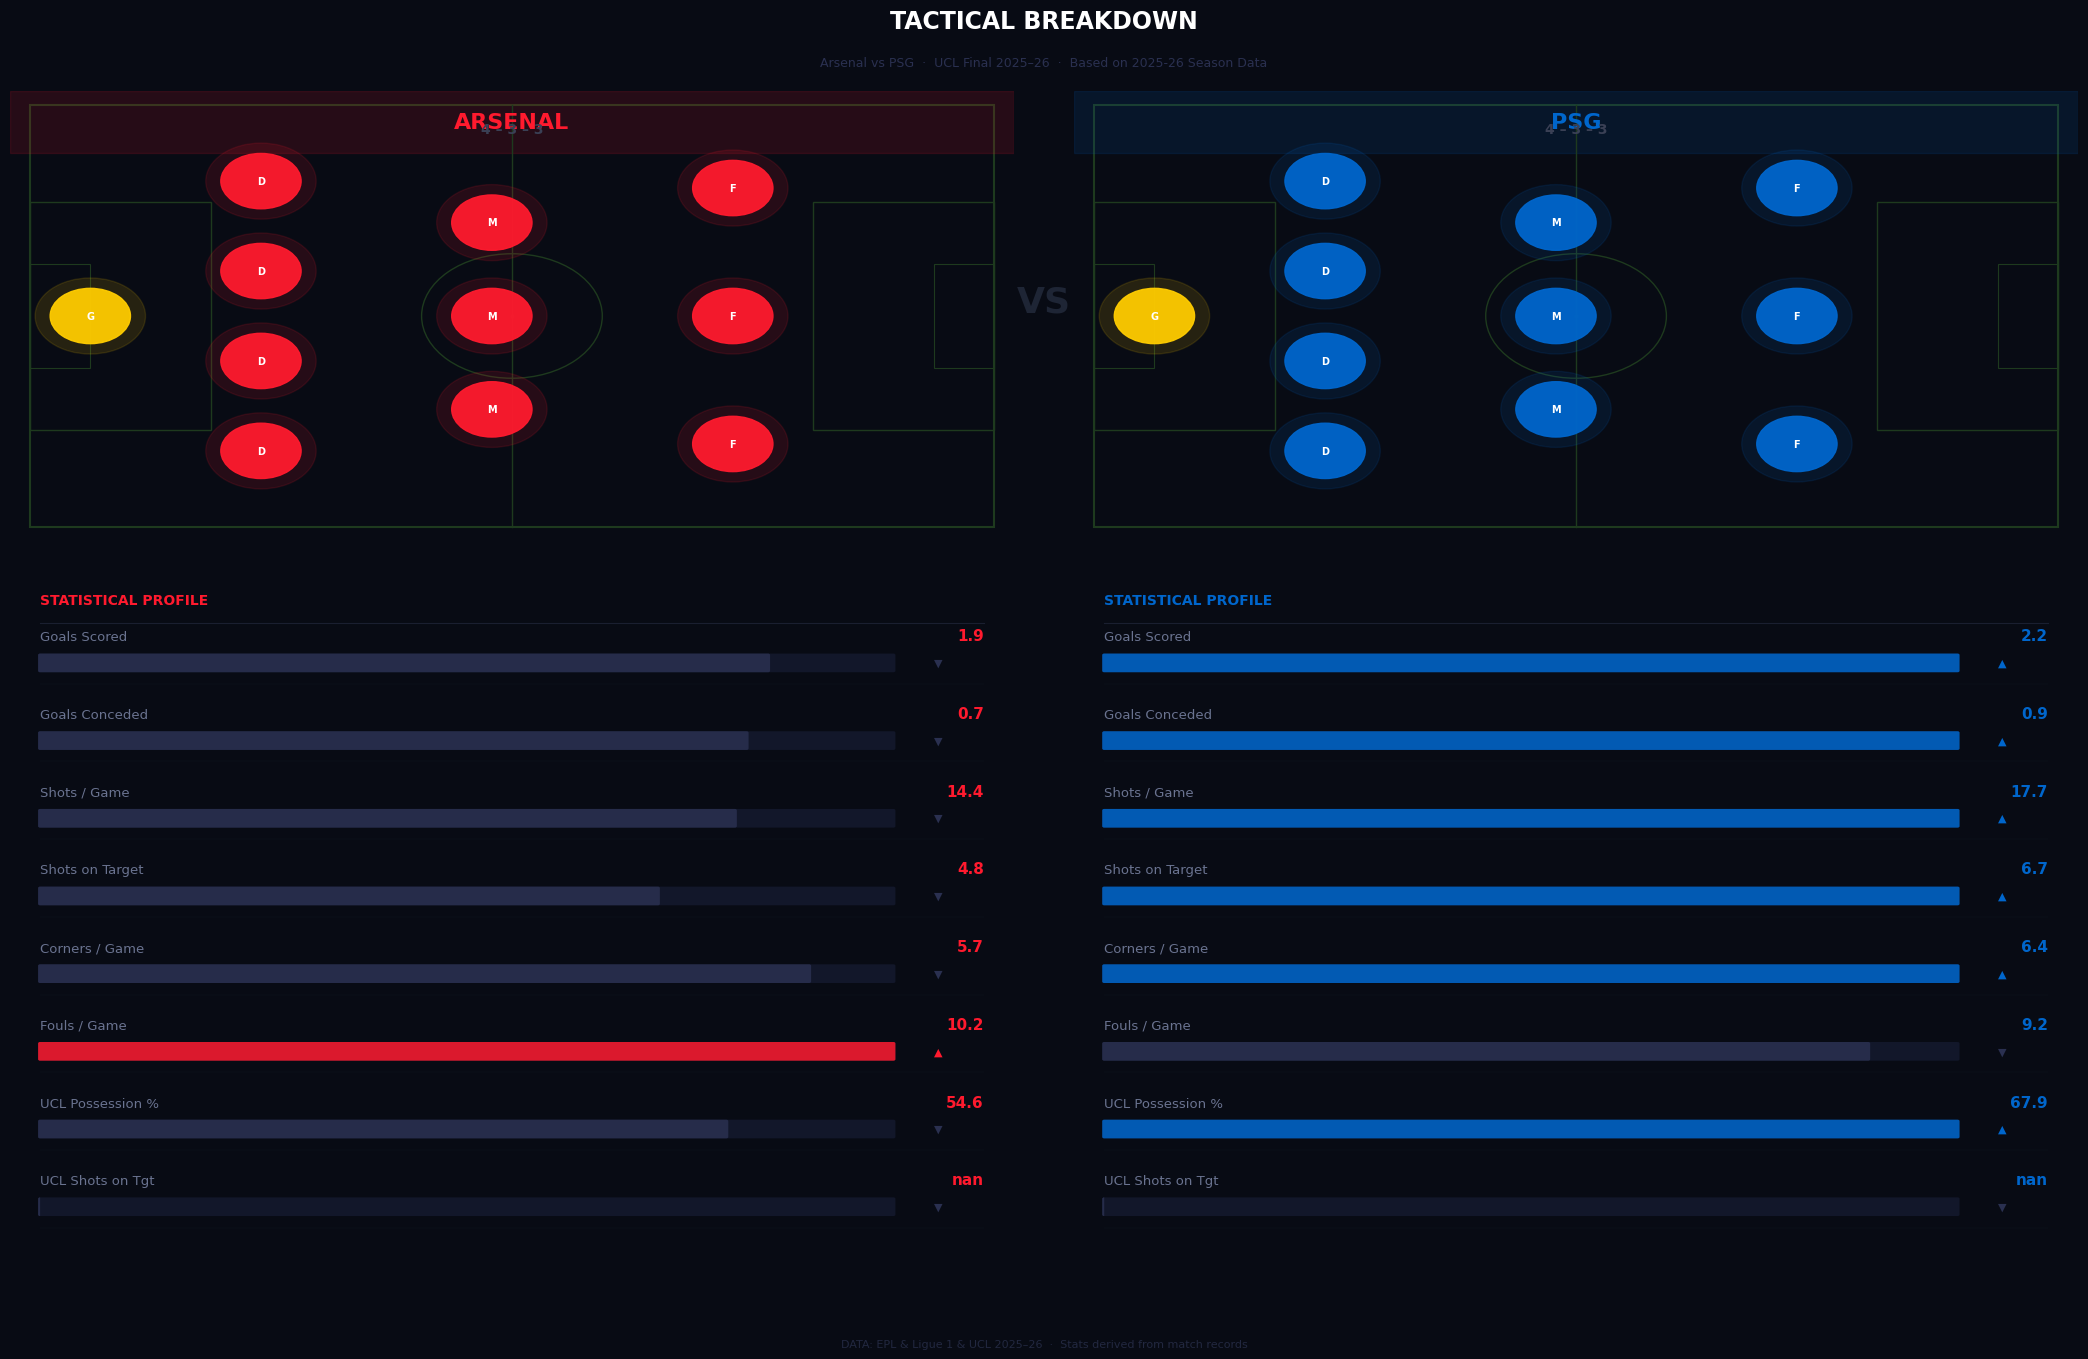

✅ Tactical breakdown saved!


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Load Data ──
ucl = pd.read_csv("ucl match stats/champions_league_matches.csv")
epl = pd.read_csv("epl.csv")
l1  = pd.read_csv("league 1.csv")

# ── Filter ──
ars_home = epl[epl['HomeTeam'] == 'Arsenal']
ars_away = epl[epl['AwayTeam'] == 'Arsenal']
psg_home = l1[l1['HomeTeam'] == 'Paris SG']
psg_away = l1[l1['AwayTeam'] == 'Paris SG']

def ucl_stat(df, team, col):
    home = pd.to_numeric(df[df['home_team'] == team][f'home_{col}']
           .astype(str).str.replace('%','').str.strip(), errors='coerce').mean()
    away = pd.to_numeric(df[df['away_team'] == team][f'away_{col}']
           .astype(str).str.replace('%','').str.strip(), errors='coerce').mean()
    return round((home + away) / 2, 1)

def league_stat(home_df, away_df, h_col, a_col):
    return (home_df[h_col].mean() + away_df[a_col].mean()) / 2

# ── Compute Stats ──
stats_raw = {
    'Arsenal': {
        'Goals Scored':      league_stat(ars_home, ars_away, 'FTHG', 'FTAG'),
        'Goals Conceded':    league_stat(ars_home, ars_away, 'FTAG', 'FTHG'),
        'Shots / Game':      league_stat(ars_home, ars_away, 'HS',   'AS'),
        'Shots on Target':   league_stat(ars_home, ars_away, 'HST',  'AST'),
        'Corners / Game':    league_stat(ars_home, ars_away, 'HC',   'AC'),
        'Fouls / Game':      league_stat(ars_home, ars_away, 'HF',   'AF'),
        'UCL Possession %':  ucl_stat(ucl, 'Arsenal',             'possession'),
        'UCL Shots on Tgt':  ucl_stat(ucl, 'Arsenal',             'shots_on_target'),
    },
    'PSG': {
        'Goals Scored':      league_stat(psg_home, psg_away, 'FTHG', 'FTAG'),
        'Goals Conceded':    league_stat(psg_home, psg_away, 'FTAG', 'FTHG'),
        'Shots / Game':      league_stat(psg_home, psg_away, 'HS',   'AS'),
        'Shots on Target':   league_stat(psg_home, psg_away, 'HST',  'AST'),
        'Corners / Game':    league_stat(psg_home, psg_away, 'HC',   'AC'),
        'Fouls / Game':      league_stat(psg_home, psg_away, 'HF',   'AF'),
        'UCL Possession %':  ucl_stat(ucl, 'Paris Saint-Germain',   'possession'),
        'UCL Shots on Tgt':  ucl_stat(ucl, 'Paris Saint-Germain',   'shots_on_target'),
    }
}

BG    = '#080b14'
CARD  = '#0e1220'
INNER = '#12172a'
GRID  = '#1a1f30'
ARS   = '#ff1a2e'
PSG   = '#0066cc'

fig = plt.figure(figsize=(22, 14), facecolor=BG)

# Layout: top = pitches, bottom = stats
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.6],
                      hspace=0.06, wspace=0.06,
                      left=0.03, right=0.97,
                      top=0.91, bottom=0.05)

ax_pitch_a = fig.add_subplot(gs[0, 0])
ax_pitch_p = fig.add_subplot(gs[0, 1])
ax_stats_a = fig.add_subplot(gs[1, 0])
ax_stats_p = fig.add_subplot(gs[1, 1])

# ══════════════════════════════════════════
# PITCH PANELS
# ══════════════════════════════════════════
def draw_pitch(ax, team, color):
    ax.set_facecolor('#060d06')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 65)
    ax.axis('off')

    # Pitch outline
    ax.add_patch(plt.Rectangle((2, 2), 96, 61,
                 fill=False, edgecolor='#1e3a1e', linewidth=1.5))
    # Centre line
    ax.plot([50, 50], [2, 63], color='#1e3a1e', linewidth=1)
    # Centre circle
    ax.add_patch(plt.Circle((50, 32.5), 9,
                 fill=False, edgecolor='#1e3a1e', linewidth=1))
    ax.plot(50, 32.5, 'o', color='#1e3a1e', markersize=2)
    # Penalty boxes
    ax.add_patch(plt.Rectangle((2, 16), 18, 33,
                 fill=False, edgecolor='#1e3a1e', linewidth=1))
    ax.add_patch(plt.Rectangle((80, 16), 18, 33,
                 fill=False, edgecolor='#1e3a1e', linewidth=1))
    # 6-yard boxes
    ax.add_patch(plt.Rectangle((2, 25), 6, 15,
                 fill=False, edgecolor='#1e3a1e', linewidth=0.8))
    ax.add_patch(plt.Rectangle((92, 25), 6, 15,
                 fill=False, edgecolor='#1e3a1e', linewidth=0.8))

    # 4-3-3: GK=1, DEF=4, MID=3, FWD=3
    # Attacking left to right
    positions = {
        'GK':  [(8,  32.5)],
        'DEF': [(25, 13), (25, 26), (25, 39), (25, 52)],
        'MID': [(48, 19), (48, 32.5), (48, 46)],
        'FWD': [(72, 14), (72, 32.5), (72, 51)],
    }
    role_colors = {'GK': '#ffcc00', 'DEF': color, 'MID': color, 'FWD': color}

    for role, pts in positions.items():
        for (x, y) in pts:
            # Glow
            ax.add_patch(plt.Circle((x, y), 5.5, color=role_colors[role],
                         alpha=0.12, zorder=3))
            # Main dot
            ax.add_patch(plt.Circle((x, y), 4, color=role_colors[role],
                         alpha=0.95, zorder=4))
            # Role label
            ax.text(x, y, role[0], ha='center', va='center',
                    color='white', fontsize=7, fontweight='bold', zorder=5)

    # Formation label
    ax.text(50, 59, '4 – 3 – 3', ha='center', color='#3a4055',
            fontsize=10, fontweight='bold')

    # Team header bar
    ax.add_patch(plt.Rectangle((0, 56), 100, 9,
                 color=color, alpha=0.12, zorder=1))
    ax.text(50, 60.5, team.upper(), ha='center', va='center',
            color=color, fontsize=16, fontweight='bold', zorder=2)

for ax, team, col in zip([ax_pitch_a, ax_pitch_p],
                          ['Arsenal', 'PSG'], [ARS, PSG]):
    draw_pitch(ax, team, col)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

# ══════════════════════════════════════════
# STATS PANELS
# ══════════════════════════════════════════
def draw_stats(ax, team, color, stats_a, stats_p):
    ax.set_facecolor(CARD)
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

    my   = stats_a if team == 'Arsenal' else stats_p
    them = stats_p if team == 'Arsenal' else stats_a
    keys = list(my.keys())

    # Section title
    ax.text(0.3, 9.6, 'STATISTICAL PROFILE',
            color=color, fontsize=10, fontweight='bold')
    ax.plot([0.3, 9.7], [9.35, 9.35], color=GRID, linewidth=0.8)

    row_h  = 9.1
    spacing = 1.08

    for i, key in enumerate(keys):
        y      = row_h - i * spacing
        my_val = my[key]
        th_val = them[key]
        mx     = max(my_val, th_val) if max(my_val, th_val) > 0 else 1
        won    = my_val >= th_val

        # Stat name
        ax.text(0.3, y, key, color='#6a7390', fontsize=9.5)

        # Value — right side, colored
        ax.text(9.7, y, f'{my_val:.1f}',
                color=color, fontsize=11, fontweight='bold', ha='right')

        # Bar track
        bx, bw, bh = 0.3, 8.5, 0.22
        ax.add_patch(mpatches.FancyBboxPatch(
            (bx, y - 0.42), bw, bh,
            boxstyle="round,pad=0.02",
            facecolor=INNER, edgecolor='none'))

        # Fill
        fill = (my_val / mx) * bw
        ax.add_patch(mpatches.FancyBboxPatch(
            (bx, y - 0.42), fill, bh,
            boxstyle="round,pad=0.02",
            facecolor=color if won else '#2a3050',
            edgecolor='none', alpha=0.85))

        # Win/lose triangle
        tri = '▲' if won else '▼'
        tri_col = color if won else '#2a3050'
        ax.text(9.2, y - 0.31, tri, color=tri_col, fontsize=8, va='center')

        # Divider
        ax.plot([0.3, 9.7], [y - 0.6, y - 0.6],
                color=GRID, linewidth=0.3, alpha=0.5)

    # Card border
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.05, 0.05), 9.9, 9.9, boxstyle="round,pad=0.1",
        facecolor='none', edgecolor=color, linewidth=0.8, alpha=0.2))

for ax, team, col in zip([ax_stats_a, ax_stats_p],
                          ['Arsenal', 'PSG'], [ARS, PSG]):
    draw_stats(ax, team, col, stats_raw['Arsenal'], stats_raw['PSG'])
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
        spine.set_linewidth(0.5)

# ══════════════════════════════════════════
# TITLES
# ══════════════════════════════════════════
fig.text(0.5, 0.955, 'TACTICAL BREAKDOWN',
         ha='center', color='white', fontsize=17, fontweight='bold')
fig.text(0.5, 0.928, 'Arsenal vs PSG  ·  UCL Final 2025–26  ·  Based on 2025-26 Season Data',
         ha='center', color='#2a3050', fontsize=9)
fig.text(0.5, 0.013,
         'DATA: EPL & Ligue 1 & UCL 2025–26  ·  Stats derived from match records',
         ha='center', color='#222840', fontsize=8)

# VS badge between pitches
fig.text(0.5, 0.76, 'VS', ha='center', va='center',
         color='#1e2535', fontsize=26, fontweight='bold')

plt.savefig("../Output/tactical_breakdown.png",
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Tactical breakdown saved!")

<ArrowStringArray>
[                'PSV',       'Athletic Club',   'Tottenham Hotspur',
             'Benfica',            'Juventus',         'Real Madrid',
       'Slavia Prague',          'Olympiacos',           'Liverpool',
                'Ajax',       'Bayern Munich', 'Paris Saint-Germain',
         'Club Brugge',       'FC Copenhagen',     'Manchester City',
         'Sporting CP',    'Newcastle United', 'Eintracht Frankfurt',
                   nan,            'Atalanta',             'Chelsea',
     'Atlético Madrid',               'Inter',          'Bodø/Glimt',
           'Marseille',           'FC Kairat',         'Galatasaray',
            'Pafos FC',            'Union SG',             'Arsenal',
             'Qarabağ',           'Barcelona',          'Leverkusen',
              'Napoli',            'Dortmund',              'Monaco',
          'Villarreal']
Length: 37, dtype: str
<ArrowStringArray>
[           'Union SG',             'Arsenal',          'Villarreal',
     

TypeError: Cannot perform reduction 'mean' with string dtype